In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserImputeFunctions as ui

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** 5 Impute & Prep'
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# initialize DataFrame
df_new = pd.DataFrame(columns=['column'])

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/4CleanFull_Heart_Engineer.pkl")
df_label = pd.read_pickle("../Data/4CleanFull_Label_Engineer.pkl")
df_can = pd.read_pickle("../Data/4CleanFull_CAN_Engineer.pkl")
df_don = pd.read_pickle("../Data/4CleanFull_DON_Engineer.pkl")
df_both = pd.read_pickle("../Data/4CleanFull_BOTH_Engineer.pkl")
df_nominal = pd.read_pickle("../Data/4CleanFull_Nominal_Engineer.pkl")
df_ordinal = pd.read_pickle("../Data/4CleanFull_Ordinal_Engineer.pkl")
df_numeric = pd.read_pickle("../Data/4CleanFull_Numeric_Engineer.pkl")
df_new = pd.read_pickle("../Data/4CleanFull_New_Engineer.pkl")
df_drop = pd.read_pickle("../Data/4CleanFull_Drop_Engineer.pkl")
df_dict = pd.read_pickle("../Data/4CleanFull_Dictionary_Engineer.pkl")
df_object = pd.read_pickle("../Data/4CleanFull_Object_Engineer.pkl")
df_unknown = pd.read_pickle("../Data/4CleanFull_Unknown_Engineer.pkl")
df_date = pd.read_pickle("../Data/4CleanFull_Date_Engineer.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

### Feature Information

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"New Features: {df_new.shape[0]:,}")
print(f"Drop Features: {df_drop.shape[0]:,}")
print(f"Dictionary Features: {df_object.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")

Heart Dataset Rows: 27,494 & Columns: 249
Label Features: 15
Candidate Features: 127
Donor Features: 90
Both Features: 19
Nominal Features: 176
Ordinal Features: 13
Numeric Features: 61
New Features: 22
Drop Features: 24
Dictionary Features: 0
Object Features: 0
Unknown Features: 0
Date Features: 0


### Remove Unwanted Label Features

In [4]:
# remove unwanted labels
removeCols = df_label.column[~df_label.column.isin(['TransplantSurvivalDay', 'LengthOfStay'])].to_list()

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 13 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 1 row(s) from df_ordinal DataFrame.
Remove 10 row(s) from df_nominal DataFrame.
Remove 2 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['AcuteRejectionEpisode', 'AirwayDehiscencePostTransplant', 'DialysisPostDischarge', 'FunctionalStatusFollowUp', 'GraftFailStatus', 'GraftLifeSpanDay', 'GraftStatus', 'LastFollowupNumber', 'PacemakerPostTransplant', 'RecipientStatus', 'RejectionTreatmentWithinOneYear', 'StrokePostTransplant', 'TransplantStatus']

Total Row(s) & Column(s) Before Removing Column(s): 27,494 & columns: 249
Total Row(s) & Column(s) After Removing Column(s): 27,494 & columns: 236


### Candidate Survival Information

In [5]:
# total NaNs
print("Total NaNs for TransplantSurvivalDay: ", df.TransplantSurvivalDay.isna().sum())
print("Total NaNs for LengthOfStay: ", df.LengthOfStay.isna().sum())
# print
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")

Total NaNs for TransplantSurvivalDay:  425
Total NaNs for LengthOfStay:  887
Heart Dataset Rows: 27,494 & Columns: 236


In [6]:
# labels
pd.DataFrame(df[['TransplantSurvivalDay','LengthOfStay']].describe()).T

,count,mean,std,min,25%,50%,75%,max
TransplantSurvivalDay,27069.0,1274.198012,1020.204697,0.0,364.0,1093.0,2058.0,3861.0
LengthOfStay,26607.0,22.548878,25.934613,0.0,11.0,16.0,24.0,823.0


In [7]:
# sanity check
uf.datatypeDF(df, display=True)

Total Data feature count:  236

Boolean feature count: 0
Category feature count: 76
Numeric feature count: 59
Object feature count: 101
Other feature count: 0

Total feature count:  236


### Copy DataFrame

In [8]:
# remove NaNs
df = df.dropna(subset=['TransplantSurvivalDay','LengthOfStay'])
df = df.reset_index(drop=True)
# copy dataframe
df_impute = df.copy()
# print shape
print(f"Orginal Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Impute Heart Dataset Rows: {df_impute.shape[0]:,} & Columns: {df_impute.shape[1]:,}")

Orginal Heart Dataset Rows: 26,600 & Columns: 236
Impute Heart Dataset Rows: 26,600 & Columns: 236


### Numeric Features

In [9]:
# only numerical features
numericCols = df_numeric.column.to_list()

# remove label
numericCols.remove('TransplantSurvivalDay')

# display
df[numericCols].head()

,Age_DON,Age_CAN,BMI_CAN,BMI_DON,BloodUreaNitrogenLevel_DON,WeightKg_DON,WeightKg_CAN,HeightCm_CAN,HeightCm_DON,Creatinine_DON,CreatinineTransplant_CAN,CreatinineRegistration_CAN,HemodynamicsRegistration_CO_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsTransplant_SYS_CAN,TotalDayWaitList_CAN,TotalBilirubinTransplant_CAN,TerminalTotalBilirubin_DON,OrganRecovery_PCO2_DON,Level_SGOT_AST_DON,Level_SGOT_ALT_DON,DistanceFromDonorHospitaltoTXCenter,LengthOfStay,Hematocrit_DON,IschemicTimeHour_DON,BloodPH_DON,LV_EjectionFractionPercent_DON,LungPO2_DON,LungPO2_FIO2_DON,Age_Difference,Age_Addition,HeightCm_Difference,HeightCm_Addition,WeightKg_Difference,WeightKg_Addition,BMI_Difference,BMI_Addition,Creatinine_Difference_CAN,Creatinine_Addition_CAN,Creatinine_Mean_CAN,Hemodynamics_Mean_CO_RT_CAN,Hemodynamics_Mean_PA_DIA_RT_CAN,Hemodynamics_Mean_PA_MN_RT_CAN,Hemodynamics_Mean_PCW_RT_CAN,Hemodynamics_Mean_SYS_RT_CAN,Hemodynamics_Interaction_Mean_CAN,Hemodynamics_Addition_Mean_CAN,Level_SGOT_Difference_DON,Level_SGOT_Addition_DON,TotalBilirubin_Difference,TotalBilirubin_Addition
0,31.0,45,22.061814,35.875594,18.0,107.0,65.8,172.7,172.7,1.30,1.00,1.3,2.50,2.50,34.0,34.0,37.0,37.0,36.0,36.0,50.0,50.0,11,3.6,0.4,40.0,46.0,40.0,83.0,76.0,26.2,4.9,7.38,60.0,182.0,47.0,14.0,76.0,0.0,345.4,-41.2,172.8,-13.813780,57.937408,0.30,2.30,1.150,2.50,34.0,37.0,36.5,50.0,2.295852e+06,157.5,-6.0,86.0,3.2,4.0
1,30.0,36,21.121131,22.497686,29.0,67.1,72.6,185.4,172.7,0.70,0.70,2.3,2.10,4.60,39.0,8.0,46.0,18.0,31.0,4.0,53.0,28.0,348,0.9,0.8,28.0,38.0,171.0,0.0,10.0,27.8,3.1,7.50,55.0,323.0,100.0,6.0,66.0,12.7,358.1,5.5,139.7,-1.376555,43.618816,1.60,3.00,1.500,3.35,23.5,32.0,25.0,40.5,7.614011e+05,121.0,133.0,209.0,0.1,1.7
2,15.0,58,34.493879,20.415225,15.0,59.0,106.0,175.3,170.0,0.74,2.19,1.4,5.00,4.40,23.0,21.0,32.0,22.0,13.0,13.0,52.0,28.0,55,1.2,0.7,41.0,445.0,217.0,0.0,21.0,25.4,1.4,7.40,60.0,401.0,100.0,43.0,73.0,5.3,345.3,47.0,165.0,14.078654,54.909104,-0.79,3.59,1.795,4.70,22.0,27.0,22.5,40.0,5.346008e+05,111.5,-228.0,662.0,0.5,1.9
3,47.0,66,35.222825,43.358802,29.0,115.2,111.6,178.0,163.0,1.34,1.35,1.1,4.80,4.80,12.0,12.0,22.0,22.0,12.0,12.0,34.0,34.0,392,0.7,0.3,36.0,248.0,165.0,252.0,32.0,38.3,3.5,7.37,60.0,267.0,100.0,19.0,113.0,15.0,341.0,-3.6,226.8,-8.135976,78.581627,-0.25,2.45,1.225,4.80,12.0,22.0,17.0,34.0,1.525923e+05,85.0,-83.0,413.0,0.4,1.0
4,22.0,70,24.337480,33.779330,70.0,113.0,72.0,172.0,182.9,5.10,0.80,0.8,4.75,4.75,15.0,15.0,20.0,20.0,15.0,15.0,30.0,30.0,42,0.8,0.5,33.0,137.0,174.0,60.0,26.0,30.7,2.8,7.51,55.0,209.0,100.0,48.0,92.0,-10.9,354.9,-41.0,185.0,-9.441850,58.116810,0.00,1.60,0.800,4.75,15.0,20.0,17.5,30.0,1.575003e+05,82.5,37.0,311.0,0.3,1.3


In [10]:
print(sorted(numericCols))

['Age_Addition', 'Age_CAN', 'Age_DON', 'Age_Difference', 'BMI_Addition', 'BMI_CAN', 'BMI_DON', 'BMI_Difference', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_Addition_CAN', 'Creatinine_DON', 'Creatinine_Difference_CAN', 'Creatinine_Mean_CAN', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_Addition', 'HeightCm_CAN', 'HeightCm_DON', 'HeightCm_Difference', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'Hemodynamics_Addition_Mean_CAN', 'Hemodynamics_Interaction_Mean_CAN', 'Hemodynamics_Mean_CO_RT_CAN', 'Hemodynamics_Mean_PA_DIA_RT_CAN', 'Hemodynamics_Mean_PA_MN_RT_CAN', 'Hemodynamics_Mean_PCW_RT

#### Data Dictionary

In [11]:
df_dict[df_dict.Feature.isin(numericCols)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
7,Age_CAN,RECIPIENT AGE (YRS),TRR-CALCULATED,1987-10-01,NaT,RECIPIENT INFORMATION,NUM,,,AGE,Numeric,
8,Age_DON,DONOR AGE (YRS),DDR/LDR-CALCULATED,1987-10-01,NaT,DONOR INFORMATION,NUM,,,AGE_DON,Numeric,
16,BMI_DON,Donor BMI - Pre/At Donation Calculated,CALCULATED,NaT,NaT,,NUM,,,BMI_DON_CALC,Numeric,
21,BloodUreaNitrogenLevel_DON,DECEASED DONOR-TERMINAL BLOOD UREA NITROGEN,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,BUN_DON,Numeric,
45,Creatinine_DON,DECEASED DONOR-TERMINAL LAB CREATININE,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,CREAT_DON,Numeric,
46,CreatinineTransplant_CAN,RECIPIENT SERUM CREATININE AT TIME OF TX,TRR,1994-04-01,NaT,PRETRANSPLANT CLINICAL INFORMATION,NUM,,,CREAT_TRR,Numeric,
62,TotalDayWaitList_CAN,TOTAL DAYS ON WAITING LIST,CALCULATED,NaT,NaT,,NUM,,,DAYSWAIT_CHRON,Numeric,
77,DistanceFromDonorHospitaltoTXCenter,DISTANCE FROM DONOR HOSP TO TX CENTER (Nautical Miles),CALCULATED,NaT,NaT,,NUM,,,DISTANCE,Numeric,** LABEL ** N/Y/U/X to No/Yes/Unknown/Missing
97,BMI_CAN,Calculated Candidate BMI at Removal/Current Time,CALCULATED,NaT,NaT,,NUM,,,END_BMI_CALC,Numeric,
99,HeightCm_CAN,Calculated Candidate Height in CM at Removal/Current Time,CALCULATED,NaT,NaT,,NUM,,,END_HGT_CM_CALC,Numeric,


### Disply NaNs

In [12]:
# display NaNs
NaNs = uf.percentageNull(df_impute)
# print
NaNs

,percentage,NaNCount
Hemodynamics_Addition_Mean_CAN,4.048872,1077
Hemodynamics_Interaction_Mean_CAN,4.048872,1077
Hemodynamics_Mean_PCW_RT_CAN,3.781955,1006
HemodynamicsRegistration_PCW_CAN,3.357143,893
HemodynamicsTransplant_PCW_CAN,3.357143,893
Hemodynamics_Mean_CO_RT_CAN,2.000000,532
HemodynamicsTransplant_CO_CAN,2.000000,532
HemodynamicsRegistration_CO_CAN,2.000000,532
HemodynamicsRegistration_PA_MN_CAN,1.616541,430
Hemodynamics_Mean_PA_MN_RT_CAN,1.616541,430


### Impute Numeric Features
##### `KNN Impute:` Impute missing values in datasets using the k-Nearest Neighbors algorithm. 
- It replaces missing values with estimates based on similar data points in the dataset.
- For each sample with missing values, it finds the k nearest neighbors in the dataset.
    - It then imputes the missing value using the mean or weighted average of those neighbors' values.
- Preserves the original variable distribution.
- Does not assume any underlying data distribution.
- Can handle complex relationships in the data.
- KNN Imputation is a flexible and effective method for handling missing data, particularly when the relationships between variables are complex or non-linear.

##### Gaussian Mixture Model (GMM)
- Gaussian Mixture Model (GMM) imputation is a probabilistic approach to handling missing data by leveraging the Gaussian Mixture Model to estimate missing values based on the distribution of observed data.
- The dataset is assumed to follow a mixture of multiple Gaussian distributions.
- The Expectation-Maximization (EM) algorithm is used to estimate the parameters (means, covariances, and weights) of the Gaussian components.
Classify Data Points into Components
- Each data point is assigned a probability of belonging to each Gaussian component.
    - Impute Missing Values
        - If a feature has missing values, the missing entries are estimated using conditional probabilities derived from the Gaussian distributions.
        - Given an incomplete data point, the missing values are estimated using the conditional expectation based on the component distributions.
            - Advantages:
                - Flexible modeling: Captures multimodal distributions better than simple mean or median imputation.
                - Probabilistic approach: Accounts for uncertainty in missing data.
                - Works well with continuous data.

#### Hemodynamics
- [CO (Cardiac Output)](https://www.ncbi.nlm.nih.gov/books/NBK470455/#:~:text=Cardiac%20output%20in%20humans%20is,to%20100%20times%20each%20minute.):
    - Definition: Similar to the registration phase, it measures the heart's output during the transplant phase.
    - Importance: Critical for ensuring adequate perfusion during surgery.
    - Cardiac output in humans is generally 5-6 L/min
- [PA_DIA (Pulmonary Artery Diastolic Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK209987/):
    - Definition: Monitored to assess right heart function and pulmonary circulation during transplant.
- [PA_MN (Pulmonary Artery Mean Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK209987/):
    - Definition: Helps in evaluating pulmonary hypertension and right ventricular function.
    - Severe pulmonary hypertension artery pressure of 40 mm Hg or greater
    - Moderate pulmonary hypertension artery pressure between 25 and 39 mm Hg
    - Normal pulmonary artery pressure between 11 and 25 mm Hg
- [PCW (Pulmonary Capillary Wedge Pressure)](https://pubmed.ncbi.nlm.nih.gov/24268673/):
    - Definition: Used to monitor left ventricular function and fluid status during transplant.
- [SYS (Systemic Arterial Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK538509/):
    - Definition: Monitored to ensure stable blood pressure and perfusion during transplant.

In [13]:
features = uf.getFeatureList(df_impute, 'HemodynamicsRegistration|HemodynamicsTransplant')

                                       count       mean        std   min    25%    50%    75%    max
HemodynamicsRegistration_CO_CAN      26068.0   4.272608   1.356561  0.39   3.33   4.11   5.00   15.0
HemodynamicsRegistration_PA_DIA_CAN  26205.0  20.459653   8.682346  0.00  14.00  20.00  26.00   91.0
HemodynamicsRegistration_PA_MN_CAN   26170.0  28.527231  10.195191  0.00  21.00  28.00  36.00   96.0
HemodynamicsRegistration_PCW_CAN     25707.0  19.124673   8.824426  0.00  12.00  19.00  25.00   50.0
HemodynamicsRegistration_SYS_CAN     26212.0  41.869182  14.216455  0.00  31.00  41.00  51.00  130.0
HemodynamicsTransplant_CO_CAN        26068.0   4.521948   1.456154  0.20   3.50   4.38   5.32   15.0
HemodynamicsTransplant_PA_DIA_CAN    26205.0  19.168869   8.484892  0.00  13.00  18.00  25.00  110.0
HemodynamicsTransplant_PA_MN_CAN     26170.0  27.031698   9.918232  0.00  20.00  26.00  34.00  110.0
HemodynamicsTransplant_PCW_CAN       25707.0  17.892101   8.714694  0.00  11.00  17.00  24.

Little's MCAR test p-value: 0.0000
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


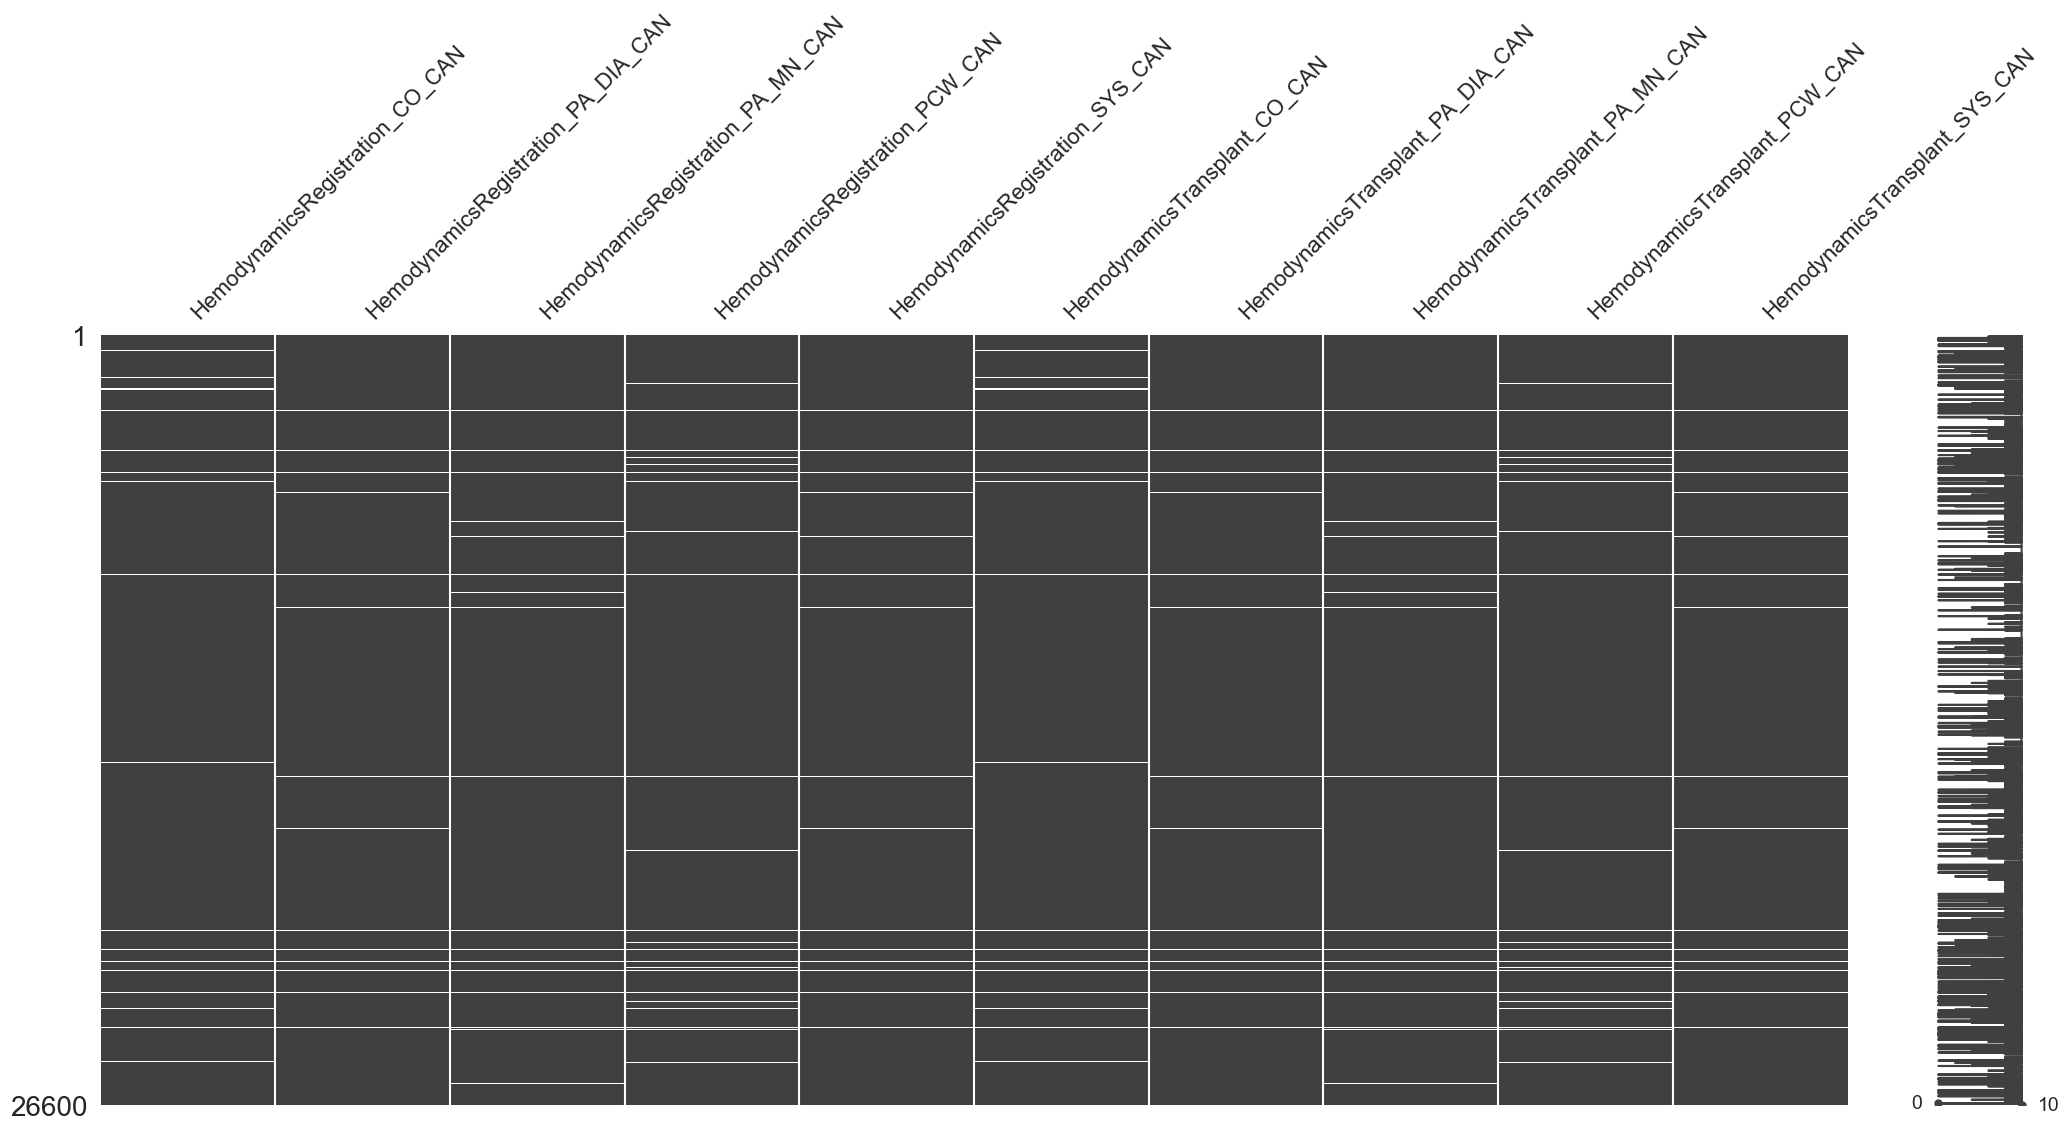

In [14]:
# stats test
usf.testMCAR(df_impute[features])
# plot missing data
uv.plotMissingData(df_impute[features])

##### Combining GMM and KNN Imputation
- Combining Gaussian Mixture Model (GMM) and k-Nearest Neighbors (KNN) imputation methods can be a robust approach for handling data that is not Missing Completely At Random (MNAR).
    - For data that is MNAR, combining these two methods can leverage the strengths of both:
        - GMM Imputation: Use GMM to estimate the missing values based on the overall distribution of the data.
        - KNN Imputation: Apply KNN to refine these estimates by considering the local structure of the data.
        - Taking the mean of the imputed values from both methods can provide a balanced estimate that accounts for both global and local patterns in the data.

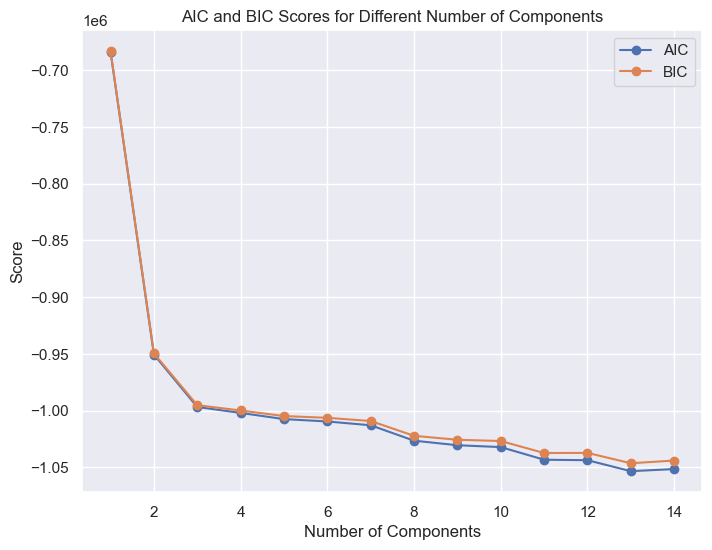

Optimal number of components: 13


In [15]:
# find components
ui.findGaussianMixtureComponents(df[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [16]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=13)

The best n_neighbors for KNN imputer is: 6
The best weights for KNN imputer is: distance


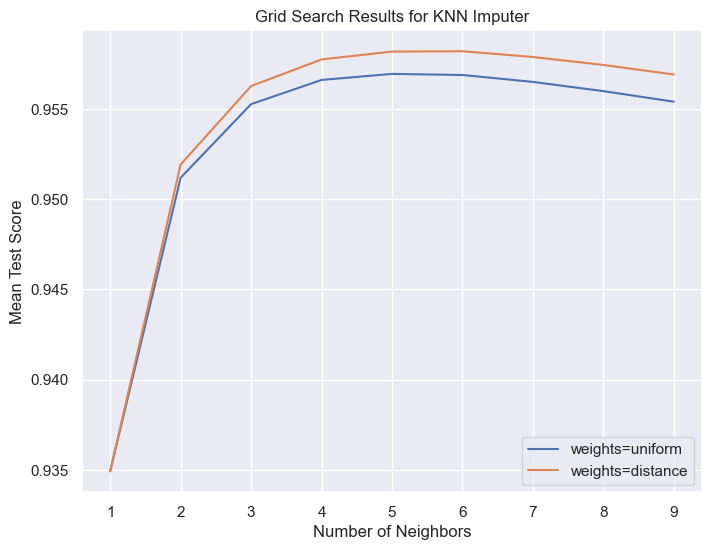

In [17]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features], n_neighbors=range(1, 10), cv=5, figsize=(8,6), flag=True)

In [18]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
HemodynamicsRegistration_CO_CAN,26600.0,4.274112,1.350346,0.39,3.34,4.120000,5.0,15.0
HemodynamicsRegistration_PA_DIA_CAN,26600.0,20.487473,8.653433,0.00,14.00,20.000000,26.0,91.0
HemodynamicsRegistration_PA_MN_CAN,26600.0,28.504454,10.149914,0.00,21.00,28.000000,35.0,96.0
HemodynamicsRegistration_PCW_CAN,26600.0,19.026402,8.724399,0.00,12.00,18.284371,25.0,50.0
HemodynamicsRegistration_SYS_CAN,26600.0,41.812677,14.163142,0.00,31.00,41.000000,51.0,130.0
HemodynamicsTransplant_CO_CAN,26600.0,4.518488,1.448696,0.20,3.50,4.370000,5.3,15.0
HemodynamicsTransplant_PA_DIA_CAN,26600.0,19.251397,8.493752,0.00,13.00,18.000000,25.0,110.0
HemodynamicsTransplant_PA_MN_CAN,26600.0,27.054225,9.885562,0.00,20.00,26.000000,34.0,110.0
HemodynamicsTransplant_PCW_CAN,26600.0,17.827394,8.606431,0.00,11.00,17.000000,24.0,50.0
HemodynamicsTransplant_SYS_CAN,26600.0,39.763216,13.757536,0.00,30.00,38.000000,49.0,159.0


In [19]:
# re-calc Registration & Transplant
df_impute['Hemodynamics_Mean_CO_RT_CAN'] = (df_impute.HemodynamicsRegistration_CO_CAN + df_impute.HemodynamicsTransplant_CO_CAN) / 2
df_impute['Hemodynamics_Mean_PA_DIA_RT_CAN'] = (df_impute.HemodynamicsRegistration_PA_DIA_CAN + df_impute.HemodynamicsTransplant_PA_DIA_CAN) /2
df_impute['Hemodynamics_Mean_PA_MN_RT_CAN'] = (df_impute.HemodynamicsRegistration_PA_MN_CAN + df_impute.HemodynamicsTransplant_PA_MN_CAN) / 2
df_impute['Hemodynamics_Mean_PCW_RT_CAN'] = (df_impute.HemodynamicsRegistration_PA_MN_CAN + df_impute.HemodynamicsTransplant_PCW_CAN) / 2
df_impute['Hemodynamics_Mean_SYS_RT_CAN'] = (df_impute.HemodynamicsRegistration_SYS_CAN + df_impute.HemodynamicsTransplant_SYS_CAN) / 2

# create new feature: add small constant to handle 0 values
df_impute['Hemodynamics_Interaction_Mean_CAN'] = (df_impute.Hemodynamics_Mean_PA_DIA_RT_CAN + 1e-5) * (df_impute.Hemodynamics_Mean_PA_MN_RT_CAN + 1e-5) * \
                                                 (df_impute.Hemodynamics_Mean_PCW_RT_CAN + 1e-5) * (df_impute.Hemodynamics_Mean_SYS_RT_CAN + 1e-5)

df_impute['Hemodynamics_Addition_Mean_CAN'] = df_impute.Hemodynamics_Mean_PA_DIA_RT_CAN +  df_impute.Hemodynamics_Mean_PA_MN_RT_CAN +  \
                                             df_impute.Hemodynamics_Mean_PCW_RT_CAN +  df_impute.Hemodynamics_Mean_SYS_RT_CAN
# print
features = uf.getFeatureList(df_impute, 'Hemodynamics')

                                       count           mean           std           min            25%            50%           75%           max
HemodynamicsRegistration_CO_CAN      26600.0       4.274112  1.350346e+00  3.900000e-01       3.340000       4.120000  5.000000e+00  1.500000e+01
HemodynamicsRegistration_PA_DIA_CAN  26600.0      20.487473  8.653433e+00  0.000000e+00      14.000000      20.000000  2.600000e+01  9.100000e+01
HemodynamicsRegistration_PA_MN_CAN   26600.0      28.504454  1.014991e+01  0.000000e+00      21.000000      28.000000  3.500000e+01  9.600000e+01
HemodynamicsRegistration_PCW_CAN     26600.0      19.026402  8.724399e+00  0.000000e+00      12.000000      18.284371  2.500000e+01  5.000000e+01
HemodynamicsRegistration_SYS_CAN     26600.0      41.812677  1.416314e+01  0.000000e+00      31.000000      41.000000  5.100000e+01  1.300000e+02
HemodynamicsTransplant_CO_CAN        26600.0       4.518488  1.448696e+00  2.000000e-01       3.500000       4.370000  5.300

#### [IschemicTimeHour](https://www.jhltonline.org/article/S1053-2498(23)01819-3/fulltext)
-  The maximum time it can be without blood supply before significant damage occurs, is around 4 hours when preserved in cold storage for transplantation; exceeding this timeframe significantly increases the risk of complications and poor outcomes after transplant. 

In [20]:
features = uf.getFeatureList(df_impute, 'IschemicTimeHour')

                        count      mean       std  min  25%  50%  75%   max
IschemicTimeHour_DON  26441.0  3.229935  1.067772  0.3  2.5  3.2  3.9  12.0

:::: NaN Count:
IschemicTimeHour_DON    159


In [21]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


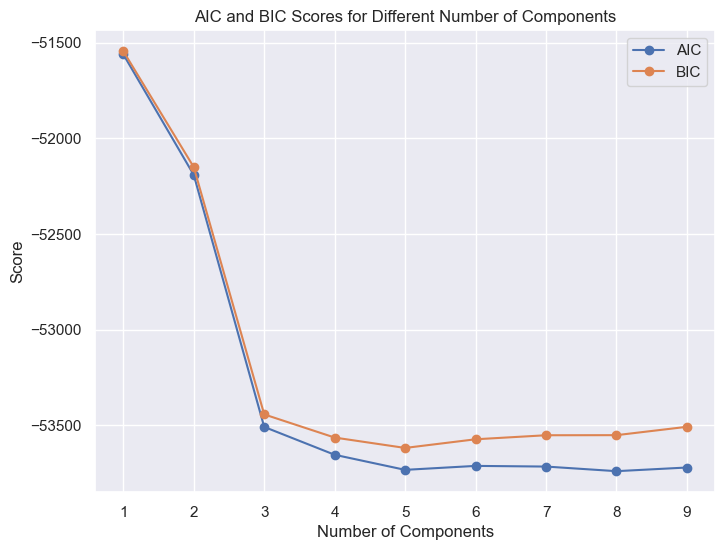

Optimal number of components: 5


In [22]:
# find components
ui.findGaussianMixtureComponents(df[features], RANDOM_STATE)

In [23]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=5)

The best n_neighbors for KNN imputer is: 2
The best weights for KNN imputer is: distance


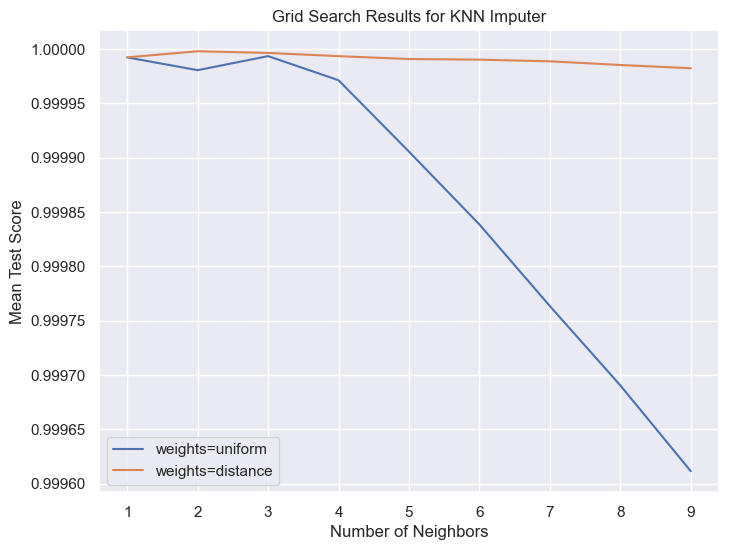

In [24]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [25]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
IschemicTimeHour_DON,26600.0,3.229909,1.065299,0.3,2.5,3.2,3.9,12.0


#### Lung PO2
- Lung PO2 (Partial Pressure of Oxygen) is a measure of the pressure exerted by oxygen in the lungs. It is an important indicator of how well oxygen is being transferred from the air in the lungs to the blood. The value of PO2 is typically measured in millimeters of mercury (mmHg) and provides insight into the efficiency of the respiratory system. In clinical and transplant contexts, particularly with donors, it helps assess the oxygenation status of the donor’s lungs, which is critical when evaluating organs for transplantation. `LungPO2_DON`: PO2 on 100% oxygen refers to the partial pressure of oxygen in arterial blood when a patient is breathing 100% oxygen.

- The Fraction of Inspired Oxygen (Lung FIO2) refers to the concentration of oxygen in the air that is being inhaled by a patient. It is a critical parameter in managing patients with respiratory distress and is often expressed as a percentage or as a decimal. `LungPO2_FIO2_DON`: Lung pO2 on FiO2 refers to the partial pressure of oxygen in arterial blood (PaO2) in relation to the fraction of inspired oxygen (FiO2).
    - Normal Range for FIO2
        - Room Air: The FIO2 in room air is approximately 21% or 0.21 as a decimal.
    - Supplemental Oxygen:
        - Low-Flow Oxygen Therapy: FIO2 can range from about 24% (0.24) to 40% (0.40), depending on the delivery device (e.g., nasal cannula, simple face mask).
        - High-Flow Oxygen Therapy: FIO2 can be set between 40% (0.40) and 100% (1.0), especially in more controlled environments like intensive care units.<br>

In [26]:
features = uf.getFeatureList(df_impute, 'LungPO2')

                    count unique      top   freq        mean         std   min    25%    50%    75%    max
LungPO2_DON       26525.0    NaN      NaN    NaN  281.005155  159.559636  7.38  131.0  258.0  425.0  698.0
LungPO2_Done_DON    26600      3  Unknown  19146         NaN         NaN   NaN    NaN    NaN    NaN    NaN
LungPO2_FIO2_DON  26447.0    NaN      NaN    NaN   82.074867   25.592334   1.0   60.0  100.0  100.0  100.0

:::: NaN Count:
LungPO2_DON          75
LungPO2_Done_DON      0
LungPO2_FIO2_DON    153


In [27]:
# add to removeCols list
removeCols = features

#### Bilirubin
- Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    - Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    - Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    - Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    - Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes. 

In [28]:
features = uf.getFeatureList(df_impute, 'TotalBilirubin.*CAN|TotalBilirubin.*DON')

                                count      mean       std  min  25%  50%  75%   max
TerminalTotalBilirubin_DON    26557.0  1.044862  1.432232  0.0  0.5  0.7  1.1  45.4
TotalBilirubinTransplant_CAN  26521.0  0.986492  1.695361  0.1  0.5  0.7  1.1  80.0

:::: NaN Count:
TerminalTotalBilirubin_DON      43
TotalBilirubinTransplant_CAN    79


In [29]:
df_impute[features].corr()

,TerminalTotalBilirubin_DON,TotalBilirubinTransplant_CAN
TerminalTotalBilirubin_DON,1.000000,0.003798
TotalBilirubinTransplant_CAN,0.003798,1.000000


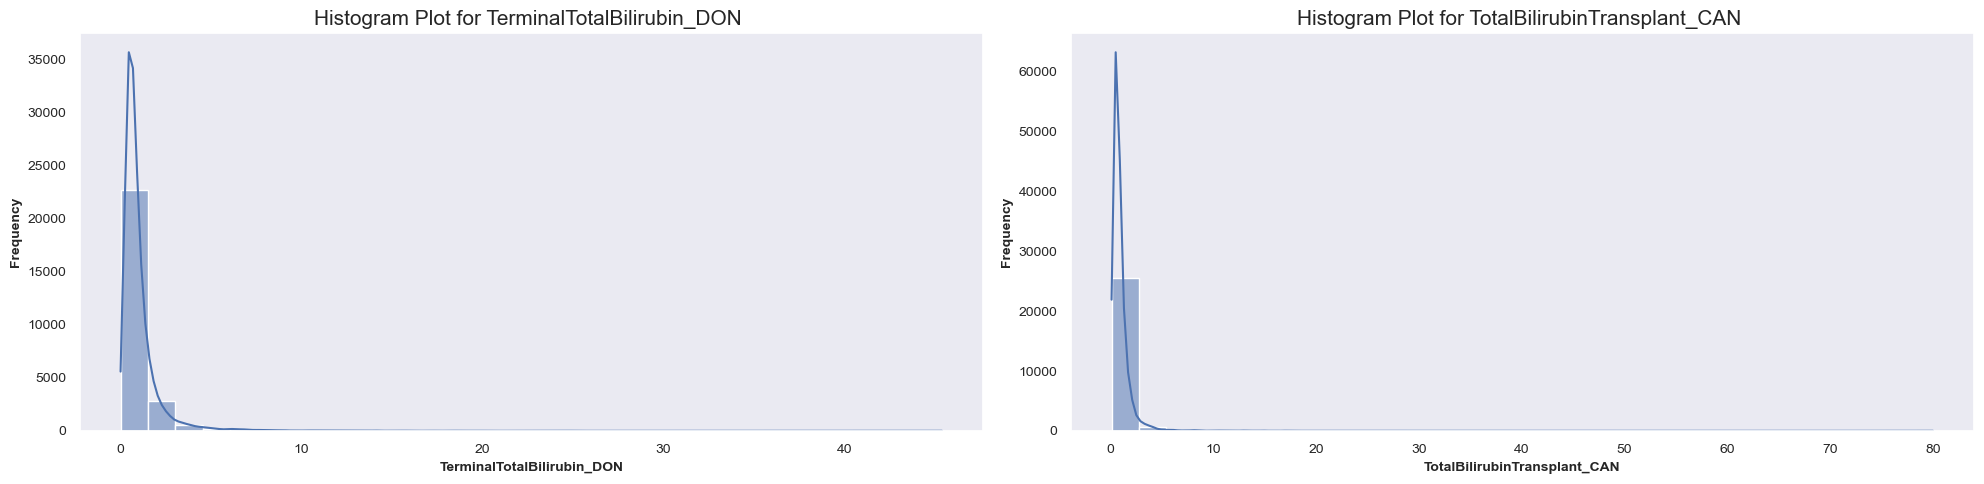

In [30]:
uv.histogramPlot(df_impute, features, bins=30)

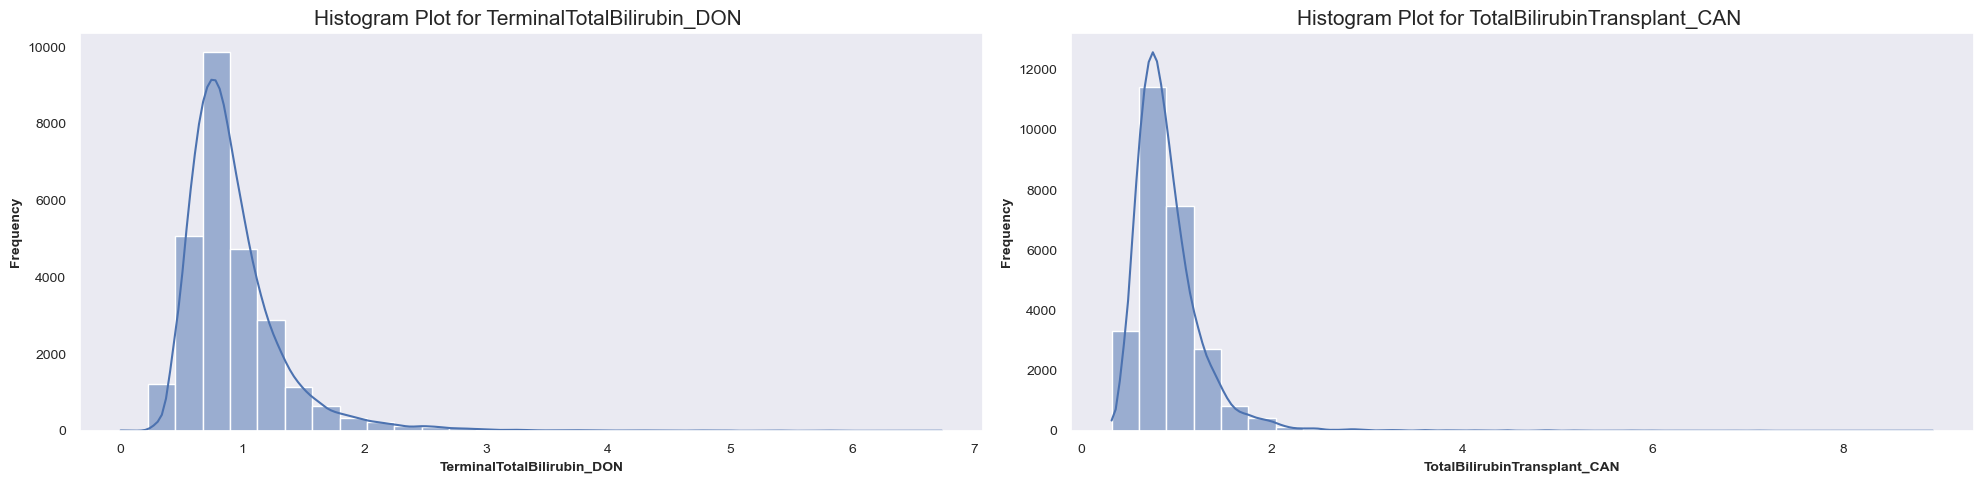

In [31]:
# transform
df_impute[features] = np.sqrt(df_impute[features])
# plot
uv.histogramPlot(df_impute, features, bins=30)

In [32]:
# stats test
usf.testMCAR(pd.DataFrame(df_impute['TerminalTotalBilirubin_DON']))

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


In [33]:
# stats test
usf.testMCAR(pd.DataFrame(df_impute['TotalBilirubinTransplant_CAN']))

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


In [34]:
df_impute[features].corr()

,TerminalTotalBilirubin_DON,TotalBilirubinTransplant_CAN
TerminalTotalBilirubin_DON,1.000000,0.009369
TotalBilirubinTransplant_CAN,0.009369,1.000000


In [35]:
pd.DataFrame(df_impute[features]).describe().T

,count,mean,std,min,25%,50%,75%,max
TerminalTotalBilirubin_DON,26557.0,0.933032,0.417517,0.000000,0.707107,0.83666,1.048809,6.737952
TotalBilirubinTransplant_CAN,26521.0,0.908933,0.400423,0.316228,0.707107,0.83666,1.048809,8.944272


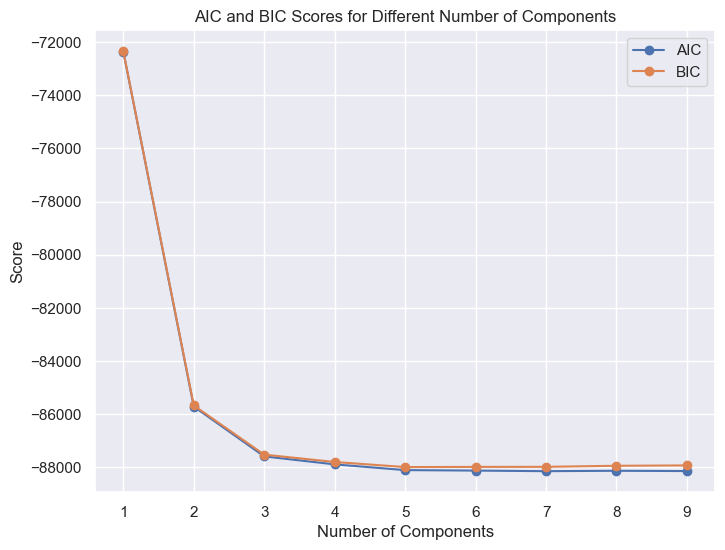

Optimal number of components: 5


In [36]:
# find components
ui.findGaussianMixtureComponents(pd.DataFrame(df_impute['TerminalTotalBilirubin_DON']), component_range=range(1, 10), seed=RANDOM_STATE)

In [37]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(pd.DataFrame(df_impute['TerminalTotalBilirubin_DON']), RANDOM_STATE, n_components=5)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


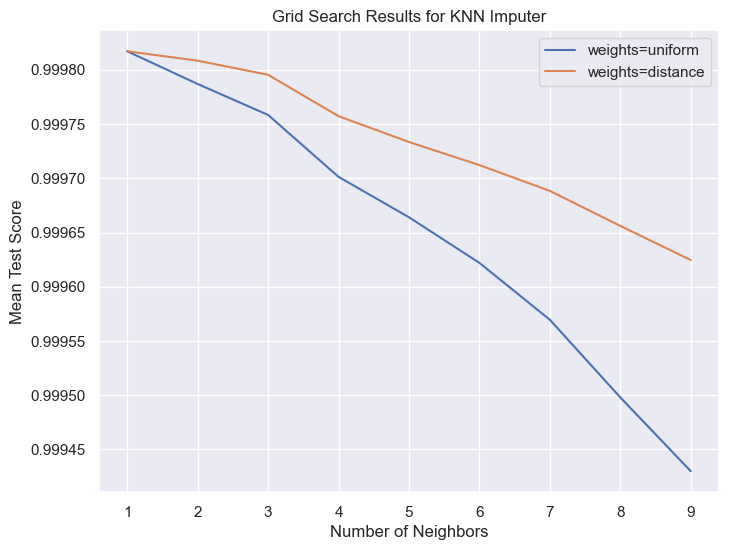

In [38]:
# impute knn
imputeKNN = ui.imputeKNN(pd.DataFrame(df_impute['TerminalTotalBilirubin_DON']))

In [39]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute['TerminalTotalBilirubin_DON'] = imputeAverage
# display
pd.DataFrame(df_impute['TerminalTotalBilirubin_DON']).describe().T

,count,mean,std,min,25%,50%,75%,max
TerminalTotalBilirubin_DON,26600.0,0.932947,0.417215,0.0,0.707107,0.83666,1.048809,6.737952


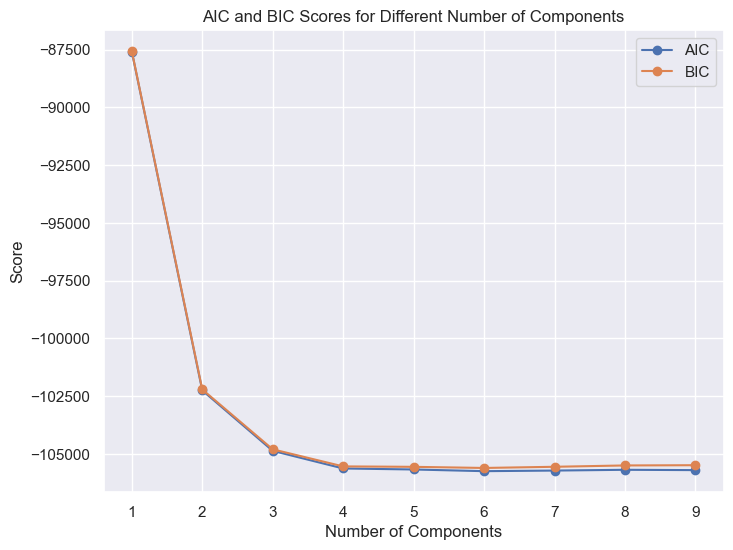

Optimal number of components: 6


In [40]:
# find components
ui.findGaussianMixtureComponents(pd.DataFrame(df_impute['TotalBilirubinTransplant_CAN']), component_range=range(1, 10), seed=RANDOM_STATE)

In [41]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(pd.DataFrame(df_impute['TotalBilirubinTransplant_CAN']), RANDOM_STATE, n_components=6)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


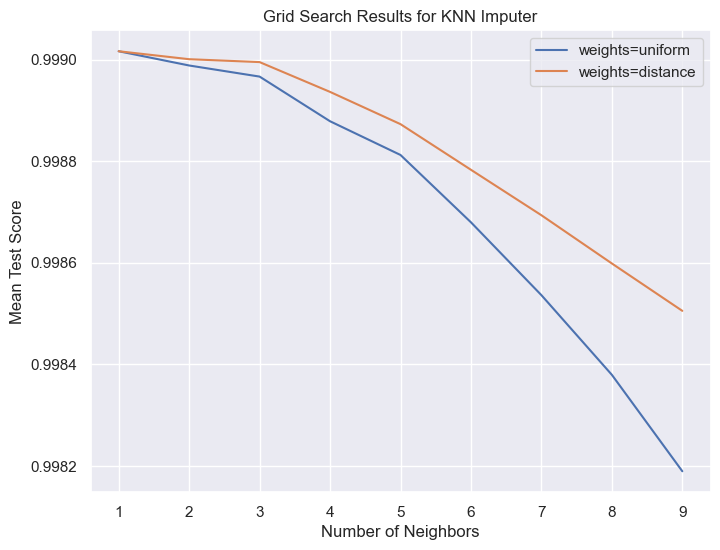

In [42]:
# impute knn
imputeKNN = ui.imputeKNN(pd.DataFrame(df_impute['TotalBilirubinTransplant_CAN']))

In [43]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute['TotalBilirubinTransplant_CAN'] = imputeAverage
# display
pd.DataFrame(df_impute['TotalBilirubinTransplant_CAN']).describe().T

,count,mean,std,min,25%,50%,75%,max
TotalBilirubinTransplant_CAN,26600.0,0.90887,0.399914,0.316228,0.707107,0.83666,1.048809,8.944272


In [44]:
# new feature
df_impute['TotalBilirubin_Difference'] = df_impute.TotalBilirubinTransplant_CAN - df_impute.TerminalTotalBilirubin_DON
df_impute['TotalBilirubin_Addition'] = df_impute.TotalBilirubinTransplant_CAN + df_impute.TerminalTotalBilirubin_DON
# display
features = uf.getFeatureList(df_impute, 'Bilirubin')

                                count      mean       std       min       25%       50%       75%       max
TerminalTotalBilirubin_DON    26600.0  0.932947  0.417215  0.000000  0.707107  0.836660  1.048809  6.737952
TotalBilirubinTransplant_CAN  26600.0  0.908870  0.399914  0.316228  0.707107  0.836660  1.048809  8.944272
TotalBilirubin_Addition       26600.0  1.841817  0.580610  0.547723  1.481703  1.730939  2.061405  9.491994
TotalBilirubin_Difference     26600.0 -0.024077  0.575232 -5.901292 -0.276062  0.000000  0.245748  8.396549

:::: NaN Count:
TerminalTotalBilirubin_DON      0
TotalBilirubinTransplant_CAN    0
TotalBilirubin_Addition         0
TotalBilirubin_Difference       0


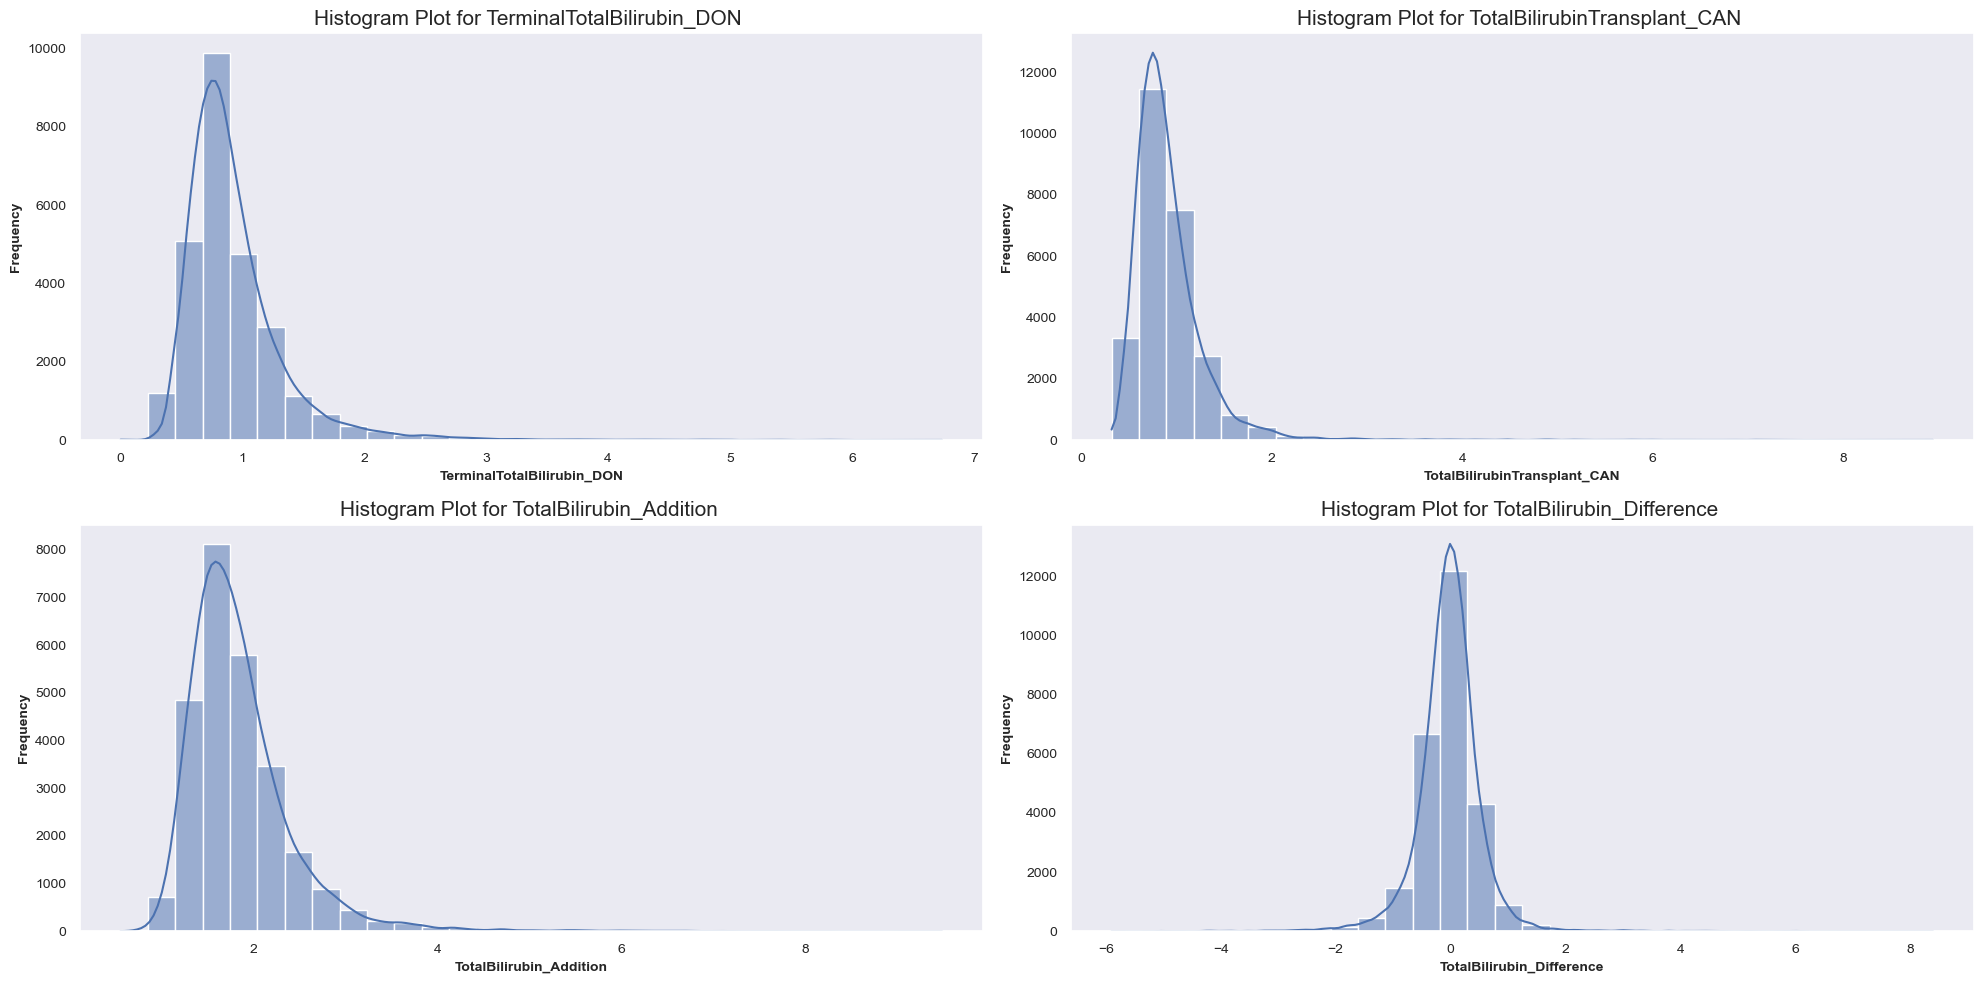

In [45]:
uv.histogramPlot(df_impute, features, bins=30)

#### [OrganRecovery_PCO2_DON](https://www.ncbi.nlm.nih.gov/books/NBK551648/)
- A blood gas test is performed to measure the amount of C02 in the blood. When the lung’s ability to exchange oxygen and C02 becomes impaired, the PC02 level may become increased. The candidate’s current PC02 and change in PC02 are both considered in the lung allocation score calculation to reflect worsening PC02 values. PCO2 is used in the Lung Allocation Score.
- The normal range for the partial pressure of carbon dioxide (pCO2) in arterial blood is typically between 35 to 45 mmHg

In [46]:
features = uf.getFeatureList(df_impute, 'OrganRecovery')

                          count       mean       std   min   25%   50%   75%    max
OrganRecovery_PCO2_DON  26531.0  38.640024  7.026554  10.1  34.0  38.0  42.1  116.3

:::: NaN Count:
OrganRecovery_PCO2_DON    69


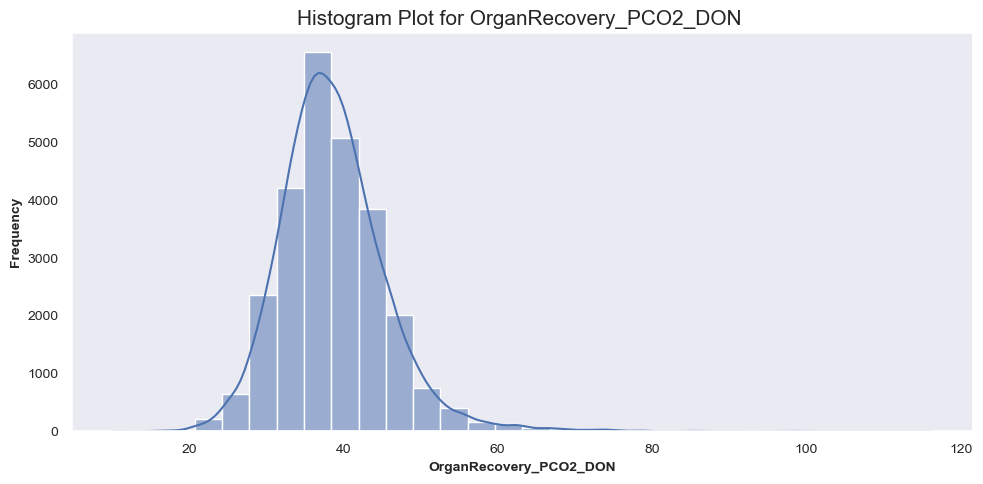

In [47]:
uv.histogramPlot(df_impute, features, bins=30)

In [48]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


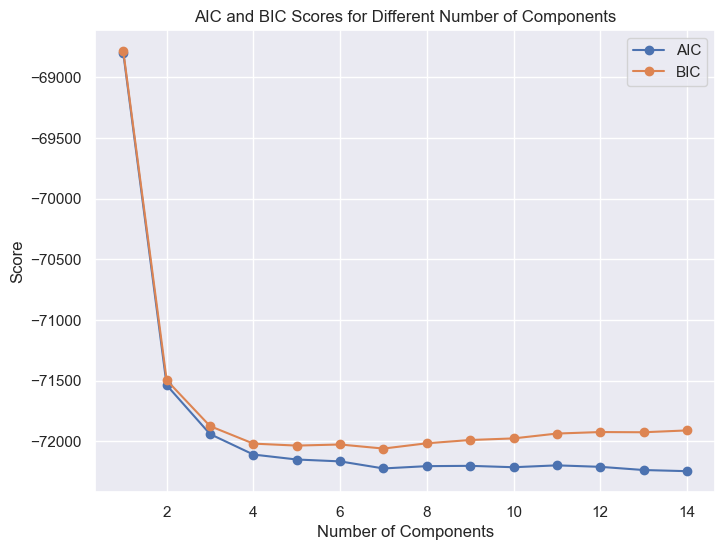

Optimal number of components: 7


In [49]:
# find components
ui.findGaussianMixtureComponents(df[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [50]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=7)

The best n_neighbors for KNN imputer is: 2
The best weights for KNN imputer is: distance


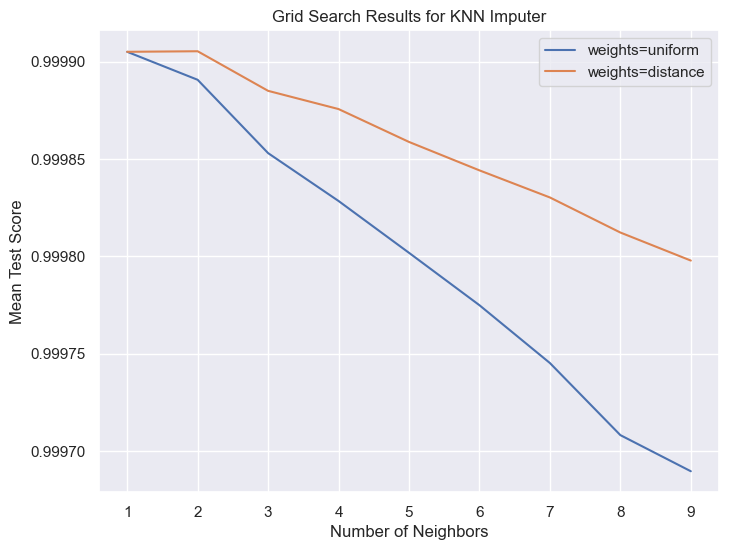

In [51]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [52]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
OrganRecovery_PCO2_DON,26600.0,38.639072,7.01932,10.1,34.0,38.0,42.1,116.3


#### BloodPH

In [53]:
features = uf.getFeatureList(df_impute, 'BloodPH')

               count      mean       std  min   25%   50%   75%   max
BloodPH_DON  26537.0  7.416184  0.071712  5.0  7.38  7.42  7.46  7.93

:::: NaN Count:
BloodPH_DON    63


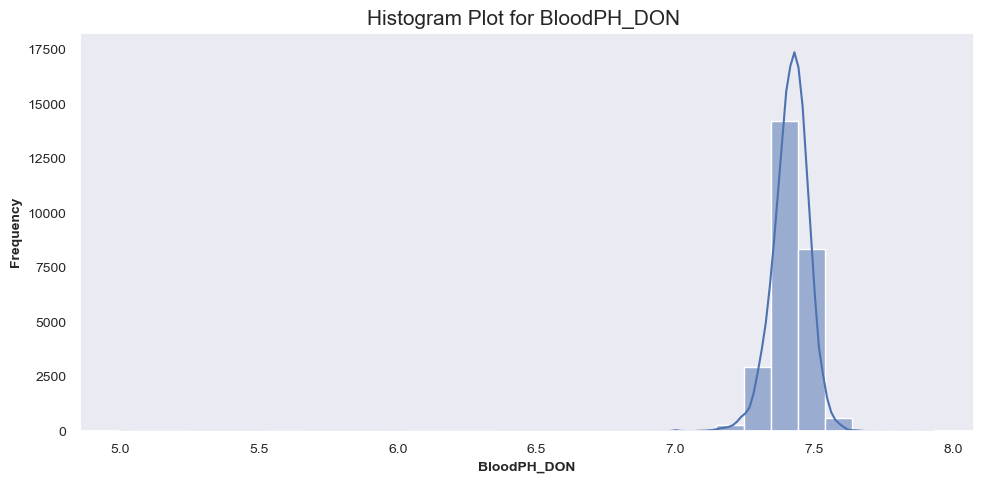

In [54]:
uv.histogramPlot(df_impute, features, bins=30)

In [55]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


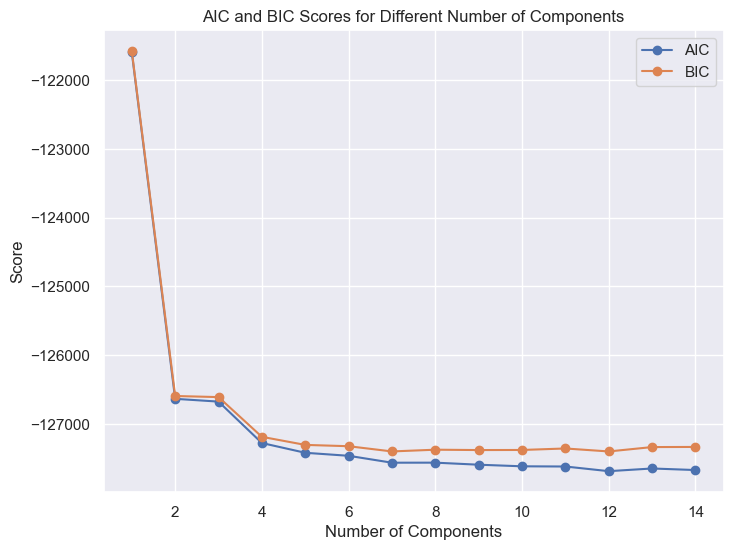

Optimal number of components: 12


In [56]:
# find components
ui.findGaussianMixtureComponents(df[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [57]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=12)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


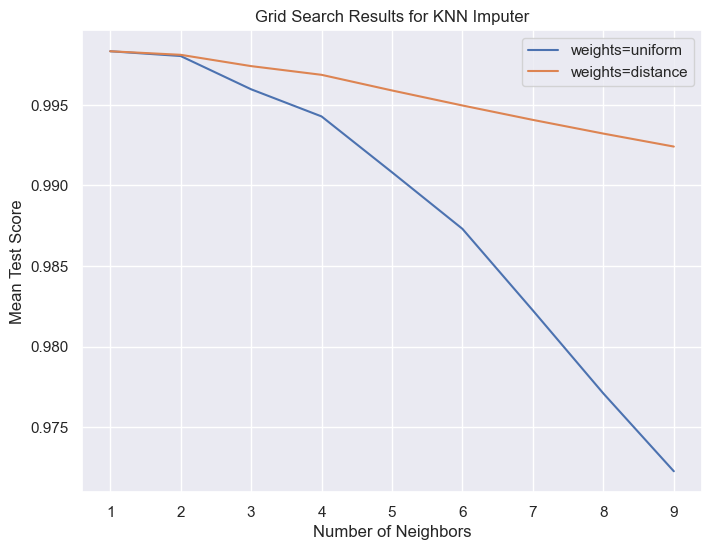

In [58]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [59]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
BloodPH_DON,26600.0,7.416174,0.071649,5.0,7.38,7.42,7.46,7.93


#### Level_SGOT
- `SGOT`, also known as aspartate aminotransferase `(AST)`, is an enzyme primarily found in the liver, heart, kidneys, and muscles. It plays a crucial role in amino acid metabolism by catalyzing the transfer of an amino group from aspartate to α-ketoglutarate, producing oxaloacetate and glutamate.
    - Conservative normal range of 8 to 45 units/L for healthy individuals. 
- Alanine aminotransferase `(ALT)`, also known as serum glutamic-pyruvic transaminase `(SGPT)`, is an enzyme primarily found in the liver. It plays a crucial role in amino acid metabolism by catalyzing the conversion of alanine and α-ketoglutarate into pyruvate and glutamate. ALT is commonly measured in blood tests to evaluate liver function and detect liver damage.
    - The typical normal range for ALT is approximately 7 to 56 units per liter (U/L) of serum. However, ranges may vary slightly between laboratories. 

In [60]:
features = uf.getFeatureList(df_impute, 'Level_SGOT_ALT|Level_SGOT_AST')

                      count        mean         std  min   25%   50%   75%      max
Level_SGOT_ALT_DON  26556.0  114.537393  410.851176  3.0  23.0  41.0  83.0  44117.0
Level_SGOT_AST_DON  26556.0  101.949910  302.800755  0.3  26.0  44.0  87.0  10254.0

:::: NaN Count:
Level_SGOT_ALT_DON    44
Level_SGOT_AST_DON    44


In [61]:
df_impute[features].corr()

,Level_SGOT_ALT_DON,Level_SGOT_AST_DON
Level_SGOT_ALT_DON,1.000000,0.551933
Level_SGOT_AST_DON,0.551933,1.000000


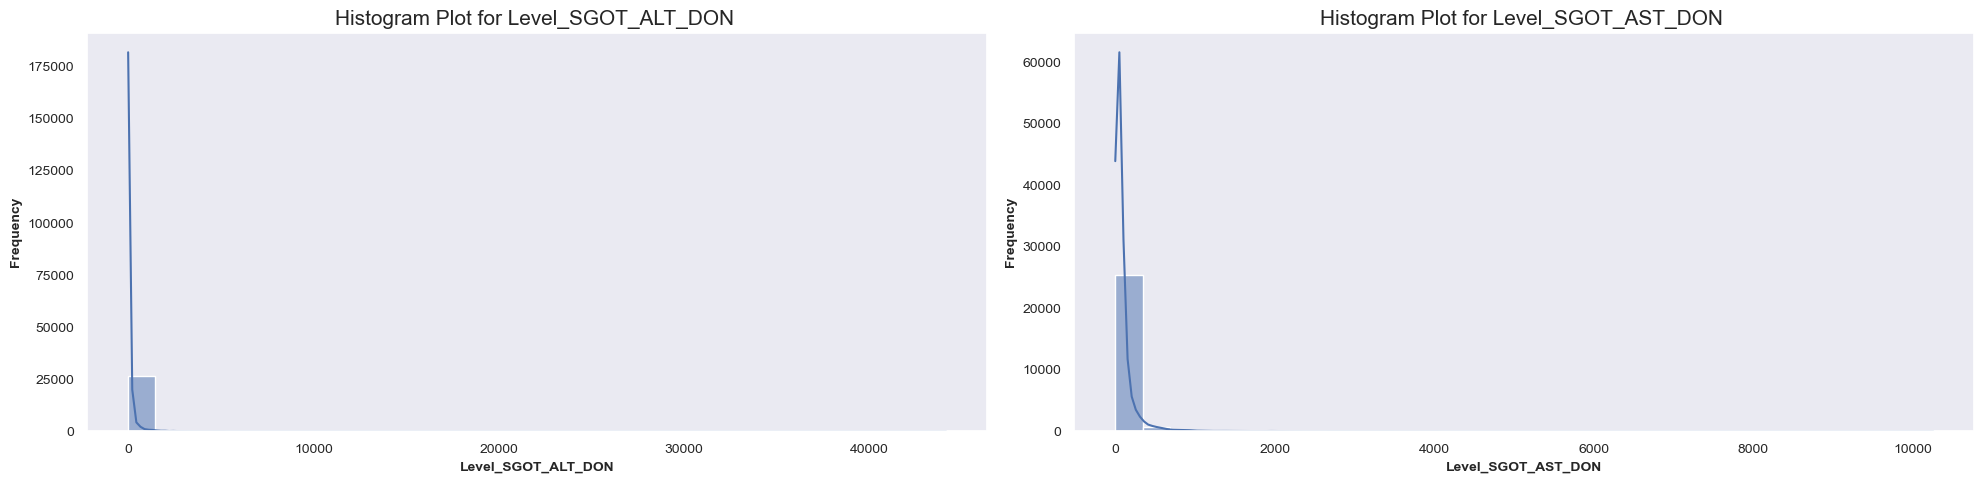

In [62]:
uv.histogramPlot(df_impute, features, bins=30)

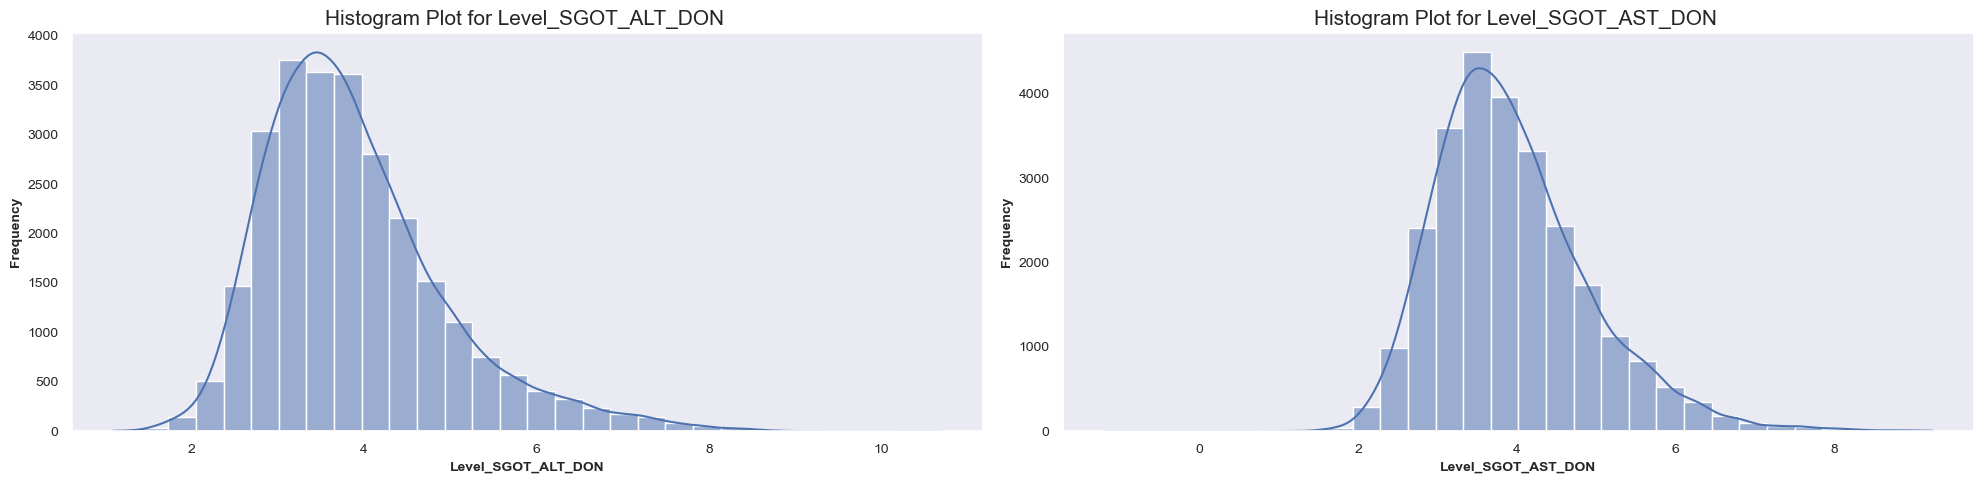

In [63]:
# transform
df_impute[features] = np.log(df_impute[features])
# plot
uv.histogramPlot(df_impute, features, bins=30)

In [64]:
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Level_SGOT_ALT_DON,26556.0,3.892872,1.064500,1.098612,3.135494,3.713572,4.418841,10.694600
Level_SGOT_AST_DON,26556.0,3.935824,0.979116,-1.203973,3.258097,3.784190,4.465908,9.235423


In [65]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


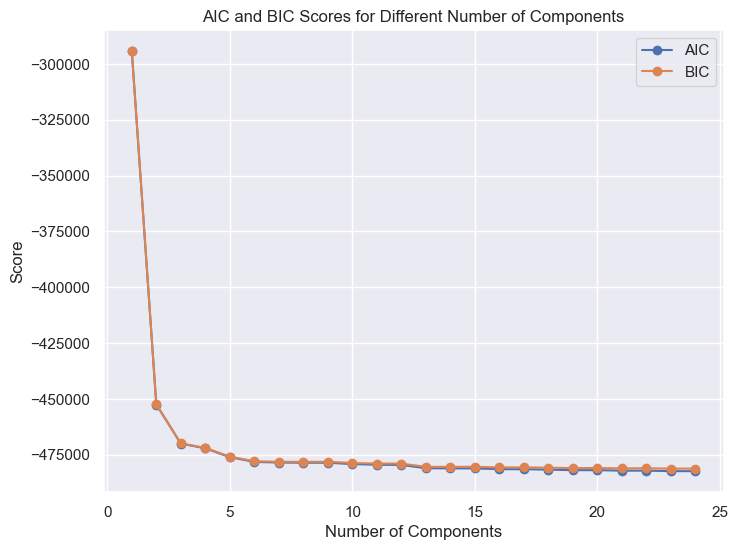

Optimal number of components: 23


In [66]:
# find components
ui.findGaussianMixtureComponents(df[features], component_range=range(1, 25), seed=RANDOM_STATE)

In [67]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=23)

The best n_neighbors for KNN imputer is: 3
The best weights for KNN imputer is: distance


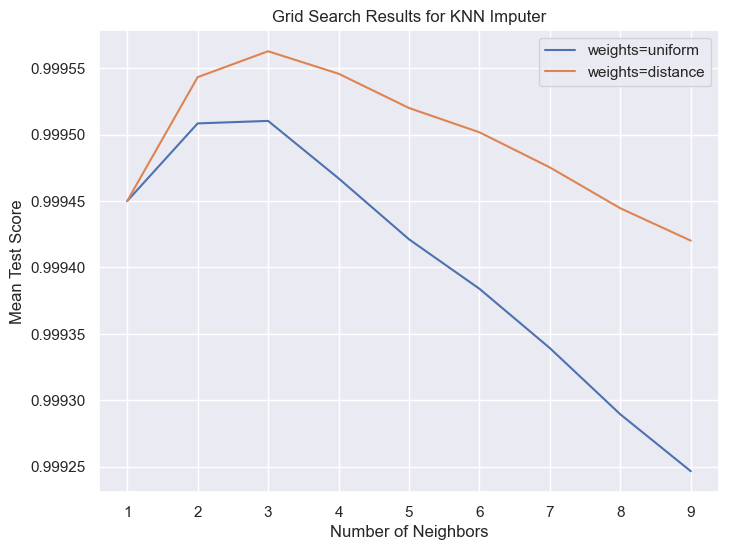

In [68]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [69]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Level_SGOT_ALT_DON,26600.0,3.893777,1.064142,1.098612,3.135494,3.713572,4.418841,10.694600
Level_SGOT_AST_DON,26600.0,3.935079,0.978899,-1.203973,3.258097,3.784190,4.465908,9.235423


In [70]:
# re-calc feature
df_impute['Level_SGOT_Difference_DON'] = df_impute.Level_SGOT_ALT_DON - df_impute.Level_SGOT_AST_DON
df_impute['Level_SGOT_Addition_DON'] = df_impute.Level_SGOT_ALT_DON + df_impute.Level_SGOT_AST_DON
# display
features = uf.getFeatureList(df_impute, 'Level_SGOT')

                             count      mean       std       min       25%       50%       75%        max
Level_SGOT_ALT_DON         26600.0  3.893777  1.064142  1.098612  3.135494  3.713572  4.418841  10.694600
Level_SGOT_AST_DON         26600.0  3.935079  0.978899 -1.203973  3.258097  3.784190  4.465908   9.235423
Level_SGOT_Addition_DON    26600.0  7.828856  1.893895  1.648659  6.527958  7.533426  8.787526  18.308192
Level_SGOT_Difference_DON  26600.0 -0.041302  0.771005 -4.926674 -0.536801 -0.077231  0.417735   5.683965

:::: NaN Count:
Level_SGOT_ALT_DON           0
Level_SGOT_AST_DON           0
Level_SGOT_Addition_DON      0
Level_SGOT_Difference_DON    0


#### [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
- Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    - Normal
        - 0.7 to 1.3 mg/dL for adult males
        - 0.5 to 1.1 mg/dL for adult females
- High creatinine levels can indicate kidney dysfunction, dehydration, or other conditions affecting the kidneys. If you have concerns about your creatinine levels, it's best to consult with a healthcare professional for proper evaluation and guidance.

In [71]:
features = uf.getFeatureList(df_impute, 'CreatinineRegistration|CreatinineTransplant')

                              count      mean       std   min   25%  50%  75%   max
CreatinineRegistration_CAN  26579.0  1.362137  0.953078  0.08  0.94  1.2  1.5  24.0
CreatinineTransplant_CAN    26579.0  1.371054  0.997589  0.06  0.94  1.2  1.5  37.0

:::: NaN Count:
CreatinineRegistration_CAN    21
CreatinineTransplant_CAN      21


In [72]:
df_impute[features].corr()

,CreatinineRegistration_CAN,CreatinineTransplant_CAN
CreatinineRegistration_CAN,1.00000,0.67348
CreatinineTransplant_CAN,0.67348,1.00000


In [73]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


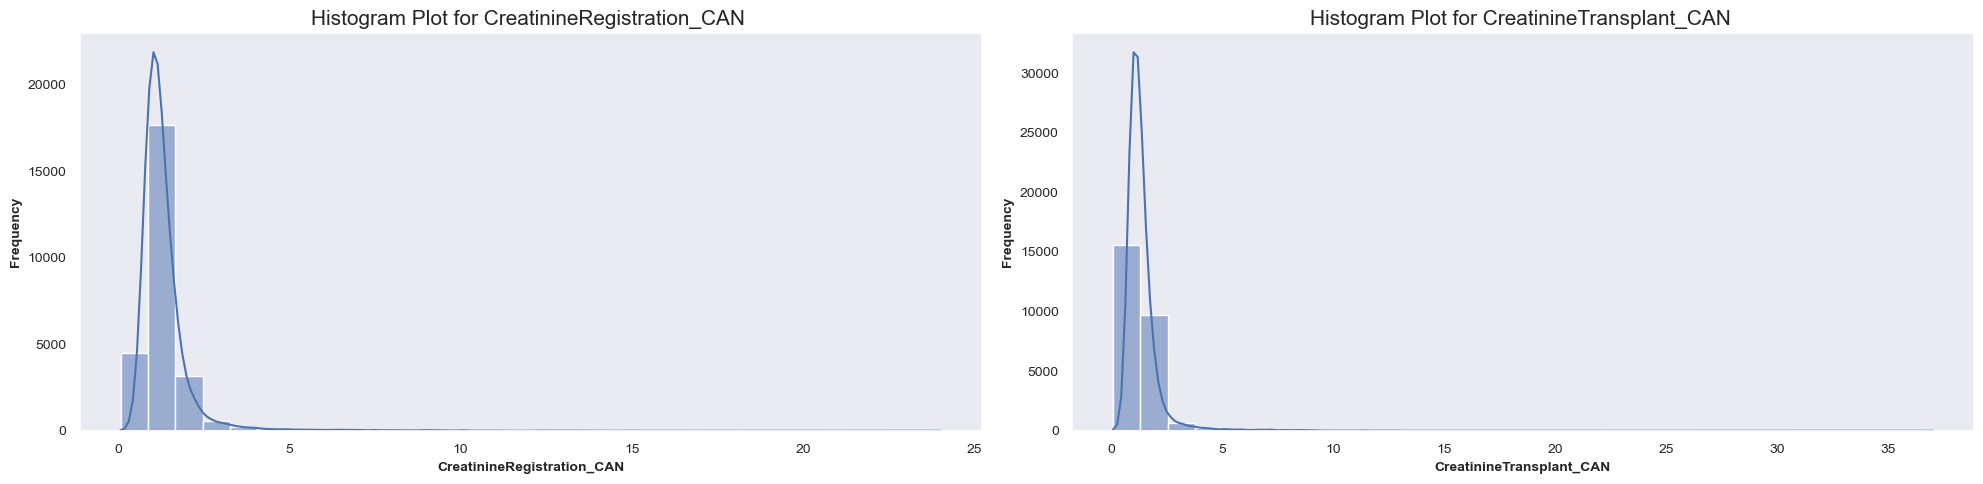

In [74]:
uv.histogramPlot(df_impute, features, bins=30)

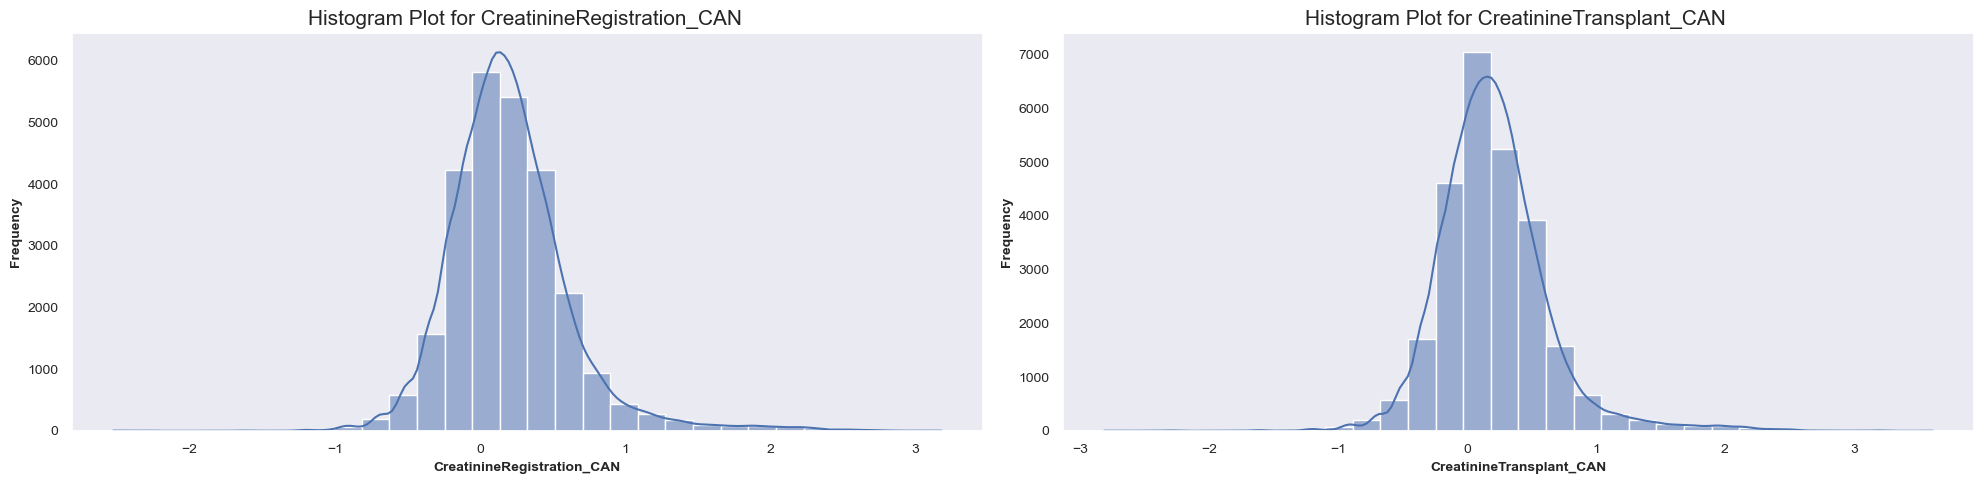

In [75]:
# transform
df_impute[features] = np.log(df_impute[features])
# plot
uv.histogramPlot(df_impute, features, bins=30)

In [76]:
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
CreatinineRegistration_CAN,26579.0,0.199937,0.416755,-2.525729,-0.061875,0.182322,0.405465,3.178054
CreatinineTransplant_CAN,26579.0,0.202368,0.425923,-2.813411,-0.061875,0.182322,0.405465,3.610918


In [77]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


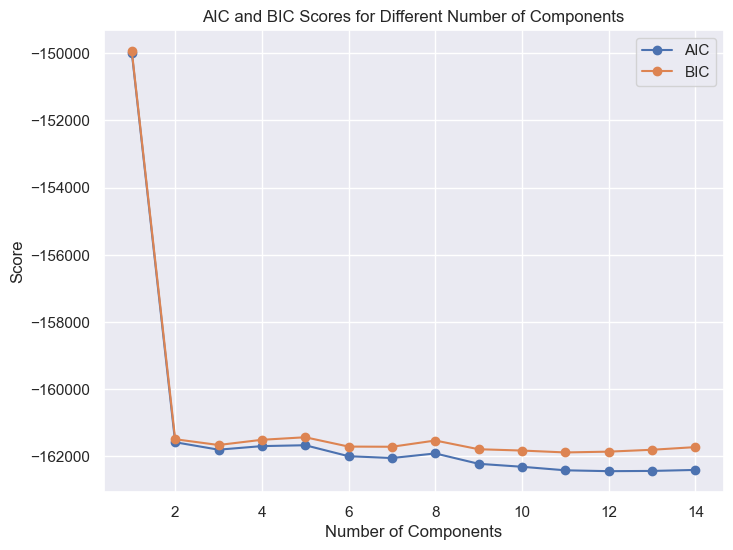

Optimal number of components: 11


In [78]:
# find components
ui.findGaussianMixtureComponents(df_impute[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [79]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=11)

The best n_neighbors for KNN imputer is: 3
The best weights for KNN imputer is: distance


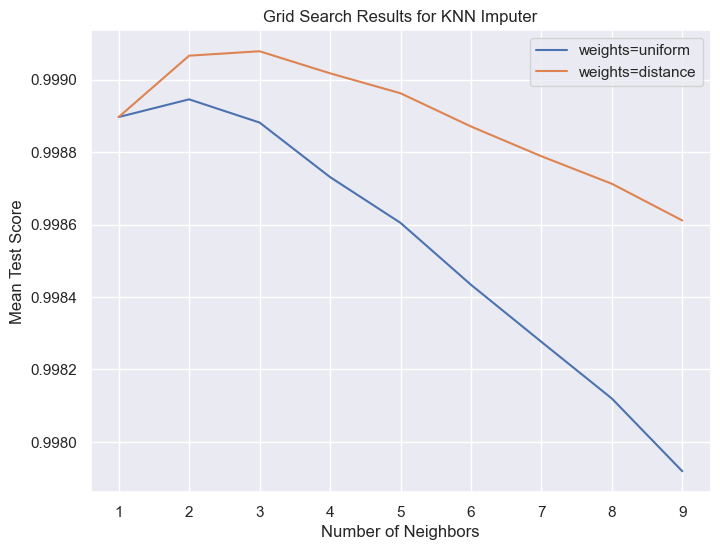

In [80]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [81]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
CreatinineRegistration_CAN,26600.0,0.199890,0.416614,-2.525729,-0.061875,0.182322,0.405465,3.178054
CreatinineTransplant_CAN,26600.0,0.202351,0.425841,-2.813411,-0.061875,0.182322,0.405465,3.610918


In [82]:
# re-calc feature
df_impute['Creatinine_Difference_CAN'] =  df_impute.CreatinineRegistration_CAN - df_impute.CreatinineTransplant_CAN
df_impute['Creatinine_Addition_CAN'] =  df_impute.CreatinineRegistration_CAN + df_impute.CreatinineTransplant_CAN
df_impute['Creatinine_Mean_CAN'] =  (df_impute.CreatinineRegistration_CAN + df_impute.CreatinineTransplant_CAN) / 2
# display
features = uf.getFeatureList(df_impute, 'Creatinine')

                              count      mean       std       min       25%           50%       75%        max
CreatinineRegistration_CAN  26600.0  0.199890  0.416614 -2.525729 -0.061875  1.823216e-01  0.405465   3.178054
CreatinineTransplant_CAN    26600.0  0.202351  0.425841 -2.813411 -0.061875  1.823216e-01  0.405465   3.610918
Creatinine_Addition_CAN     26600.0  0.402241  0.775449 -3.526761 -0.079043  3.541718e-01  0.767489   6.400922
Creatinine_DON              26560.0  1.503744  1.556497  0.040000  0.760000  1.000000e+00  1.490000  23.000000
Creatinine_Difference_CAN   26600.0 -0.002460  0.329386 -3.608837 -0.158422 -1.110223e-16  0.150282   3.705409
Creatinine_Mean_CAN         26600.0  0.201120  0.387724 -1.763380 -0.039522  1.770859e-01  0.383745   3.200461

:::: NaN Count:
CreatinineRegistration_CAN     0
CreatinineTransplant_CAN       0
Creatinine_Addition_CAN        0
Creatinine_DON                40
Creatinine_Difference_CAN      0
Creatinine_Mean_CAN            0


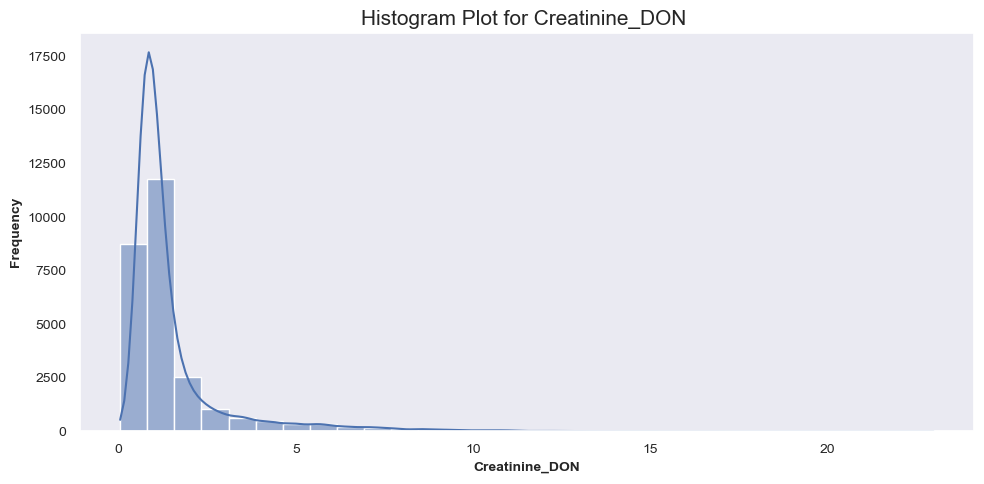

In [83]:
# initialize list
features = ['Creatinine_DON']
uv.histogramPlot(df_impute, features, bins=30)

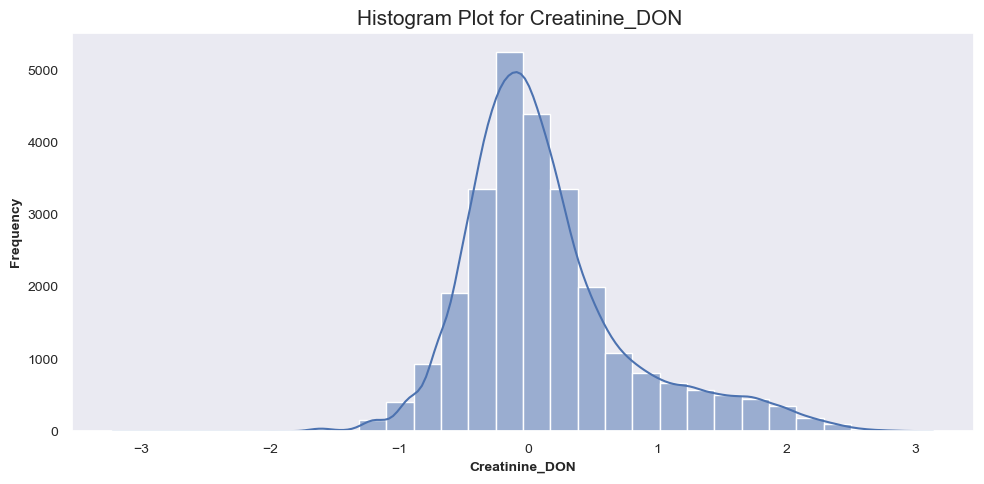

In [84]:
# transform
df_impute[features] = np.log(df_impute[features])
# plot
uv.histogramPlot(df_impute, features, bins=30)

In [85]:
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Creatinine_DON,26560.0,0.137267,0.651641,-3.218876,-0.274437,0.0,0.398776,3.135494


In [86]:
# stats test
usf.testMCAR(pd.DataFrame(df_impute[features]))

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


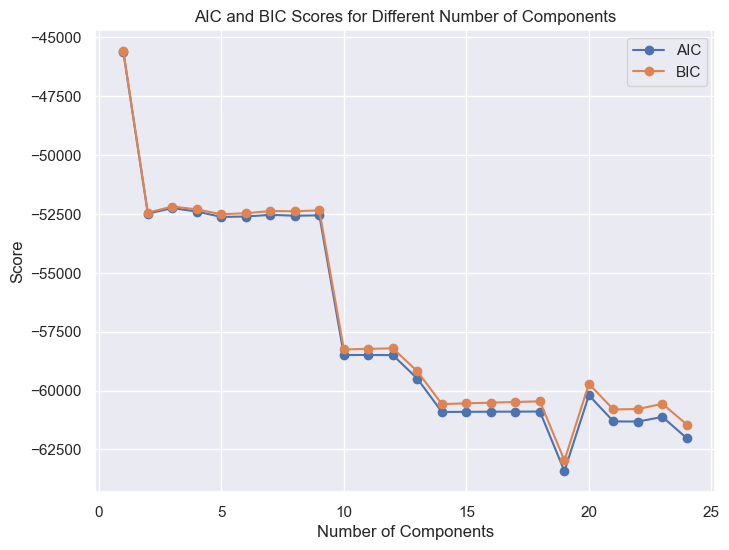

Optimal number of components: 19


In [87]:
# find components
ui.findGaussianMixtureComponents(pd.DataFrame(df_impute[features]), component_range=range(1, 25), seed=RANDOM_STATE)

In [88]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=19)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


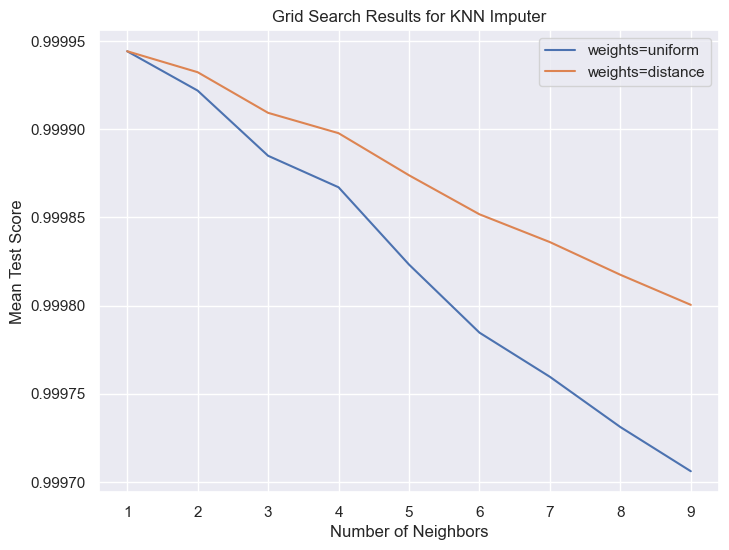

In [89]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [90]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Creatinine_DON,26600.0,0.137157,0.651232,-3.218876,-0.274437,0.0,0.398776,3.135494


In [91]:
features = uf.getFeatureList(df_impute, 'Creatinine')

                              count      mean       std       min       25%           50%       75%       max
CreatinineRegistration_CAN  26600.0  0.199890  0.416614 -2.525729 -0.061875  1.823216e-01  0.405465  3.178054
CreatinineTransplant_CAN    26600.0  0.202351  0.425841 -2.813411 -0.061875  1.823216e-01  0.405465  3.610918
Creatinine_Addition_CAN     26600.0  0.402241  0.775449 -3.526761 -0.079043  3.541718e-01  0.767489  6.400922
Creatinine_DON              26600.0  0.137157  0.651232 -3.218876 -0.274437  0.000000e+00  0.398776  3.135494
Creatinine_Difference_CAN   26600.0 -0.002460  0.329386 -3.608837 -0.158422 -1.110223e-16  0.150282  3.705409
Creatinine_Mean_CAN         26600.0  0.201120  0.387724 -1.763380 -0.039522  1.770859e-01  0.383745  3.200461

:::: NaN Count:
CreatinineRegistration_CAN    0
CreatinineTransplant_CAN      0
Creatinine_Addition_CAN       0
Creatinine_DON                0
Creatinine_Difference_CAN     0
Creatinine_Mean_CAN           0


#### BloodUreaNitrogenLevel

In [92]:
features = uf.getFeatureList(df_impute, 'BloodUreaNitrogenLevel')

                              count       mean        std  min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  26560.0  24.173811  19.996607  0.5  12.0  18.0  29.0  250.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    40


In [93]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


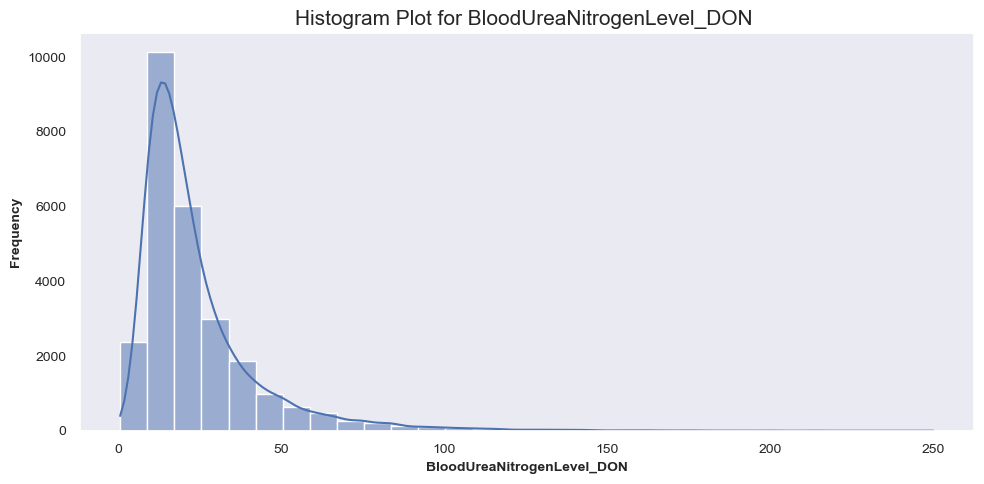

In [94]:
uv.histogramPlot(df_impute, features, bins=30)

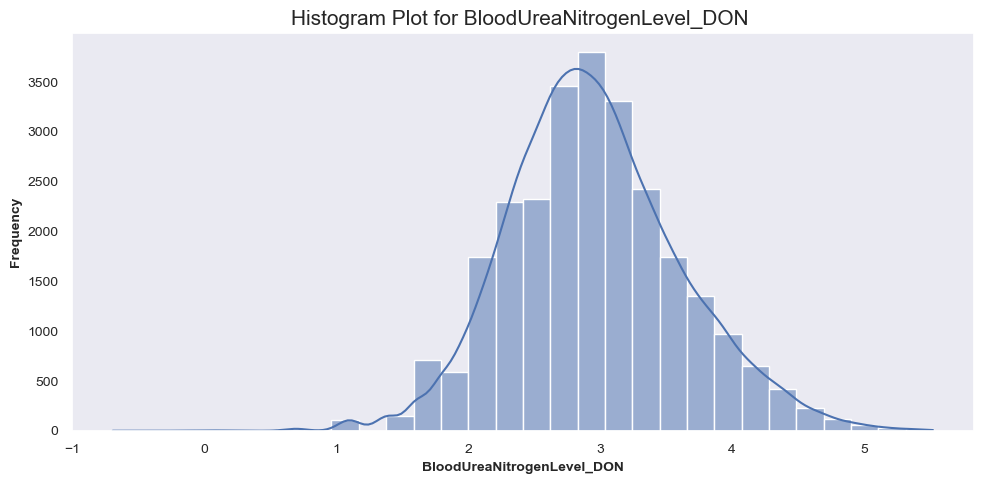

In [95]:
# transform
df_impute[features] = np.log(df_impute[features])
# plot
uv.histogramPlot(df_impute, features, bins=30)

In [96]:
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
BloodUreaNitrogenLevel_DON,26560.0,2.953209,0.659311,-0.693147,2.484907,2.890372,3.367296,5.521461


In [97]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


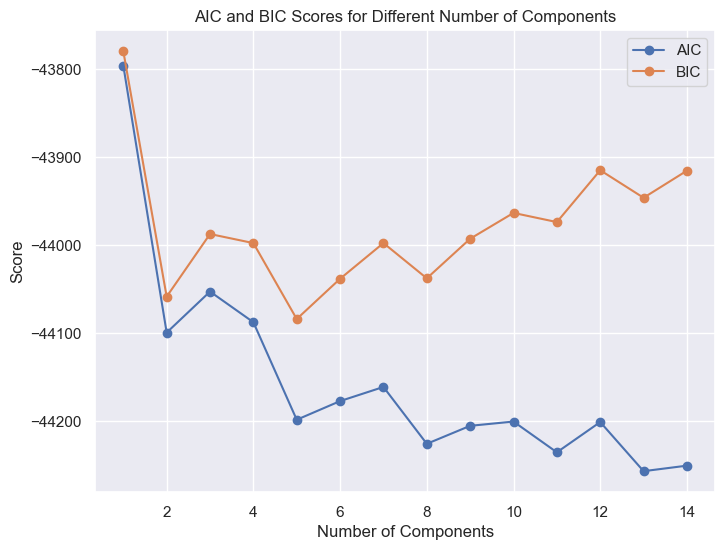

Optimal number of components: 5


In [98]:
# find components
ui.findGaussianMixtureComponents(df_impute[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [99]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=5)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


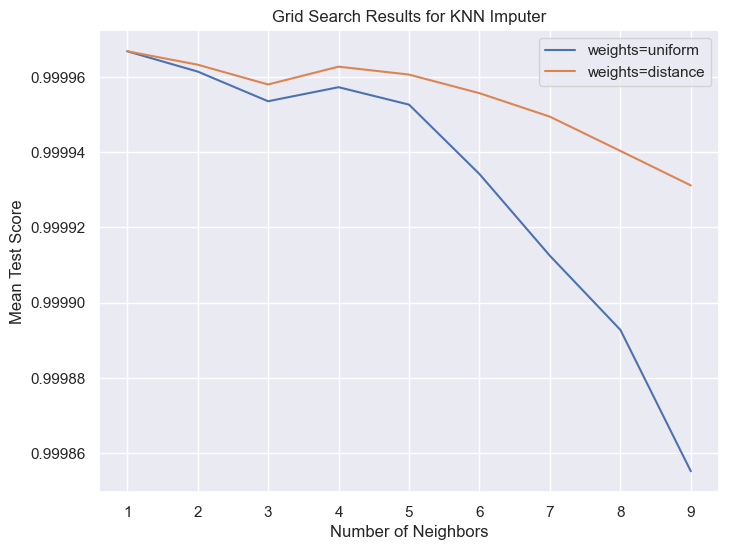

In [100]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [101]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
BloodUreaNitrogenLevel_DON,26600.0,2.953149,0.658951,-0.693147,2.484907,2.890372,3.367296,5.521461


#### [Hematocrit_DON](https://www.mountsinai.org/health-library/tests/hematocrit)
- Hematocrit is a blood test that measures how much of a person's blood is made up of red blood cells as opposed to plasma.
    - Normal results vary, but in general they are:
        - Male: 40.7% to 50.3%
        - Female: 36.1% to 44.3% 

In [102]:
features = uf.getFeatureList(df_impute, 'Hematocrit')

                  count       mean       std  min   25%   50%   75%   max
Hematocrit_DON  26560.0  28.404058  5.006004  2.3  25.0  27.9  31.3  75.0

:::: NaN Count:
Hematocrit_DON    40


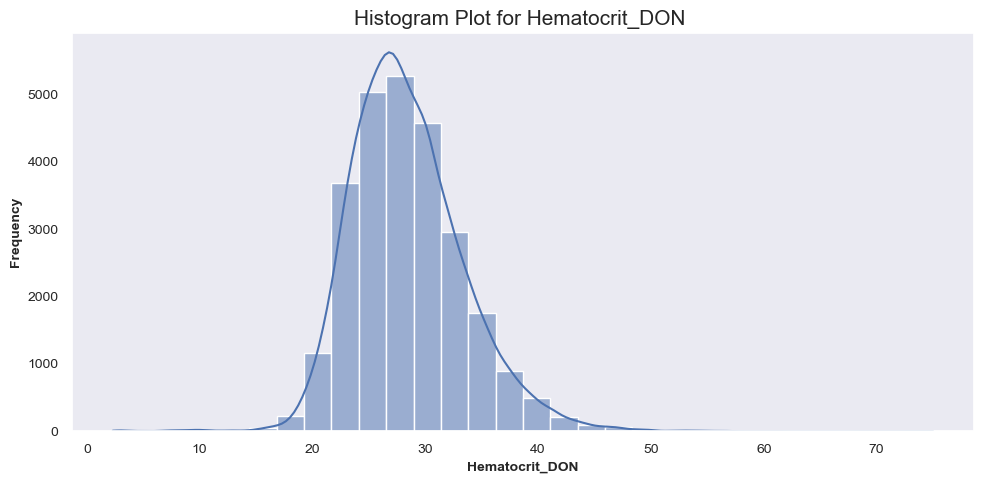

In [103]:
uv.histogramPlot(df_impute, features, bins=30)

In [104]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


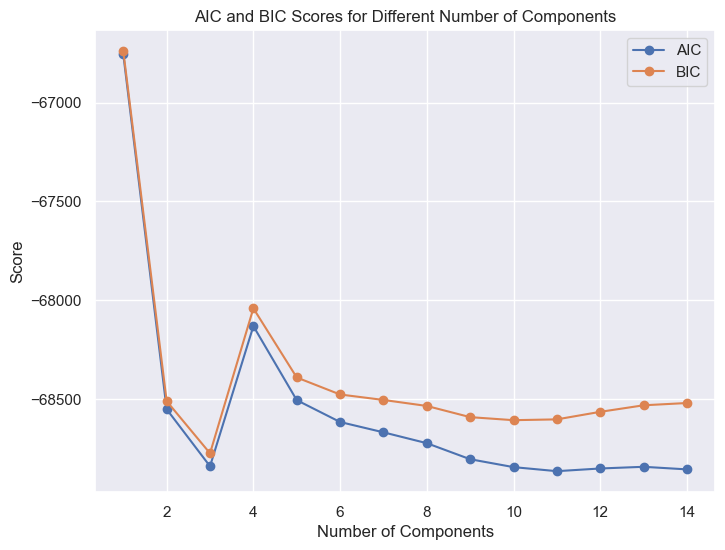

Optimal number of components: 3


In [105]:
# find components
ui.findGaussianMixtureComponents(df_impute[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [106]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=3)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


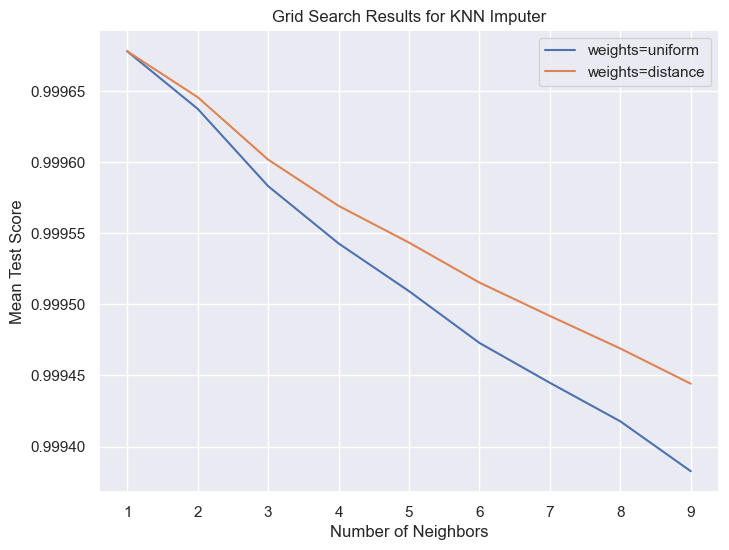

In [107]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [108]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Hematocrit_DON,26600.0,28.403919,5.003041,2.3,25.0,27.9,31.3,75.0


#### [LV_EjectionFractionPercent](https://my.clevelandclinic.org/health/articles/16950-ejection-fraction)
- Ejection fraction measures your heart’s ability to pump oxygen-rich blood out to your body. In a healthy heart, the fraction is a higher number. A low number means that your heart has difficulty keeping up with your body’s needs.
    - Male:
        - Nomal: 52% to 72%
        - Mildly Abnormal: 41% to 51%
        - Moderately Abnormal: 30% to 40%
        - Severely Abnormal: Below 30% 
    - Female:
        - Nomal: 54% to 74%
        - Mildly Abnormal: 41% to 53%
        - Moderately Abnormal: 30% to 40%
        - Severely Abnormal: Below 30% 

In [109]:
features = uf.getFeatureList(df_impute, 'LV_EjectionFractionPercent')

                                  count       mean      std   min   25%   50%   75%   max
LV_EjectionFractionPercent_DON  26573.0  61.619139  6.64542  10.0  56.0  60.0  65.0  99.0

:::: NaN Count:
LV_EjectionFractionPercent_DON    27


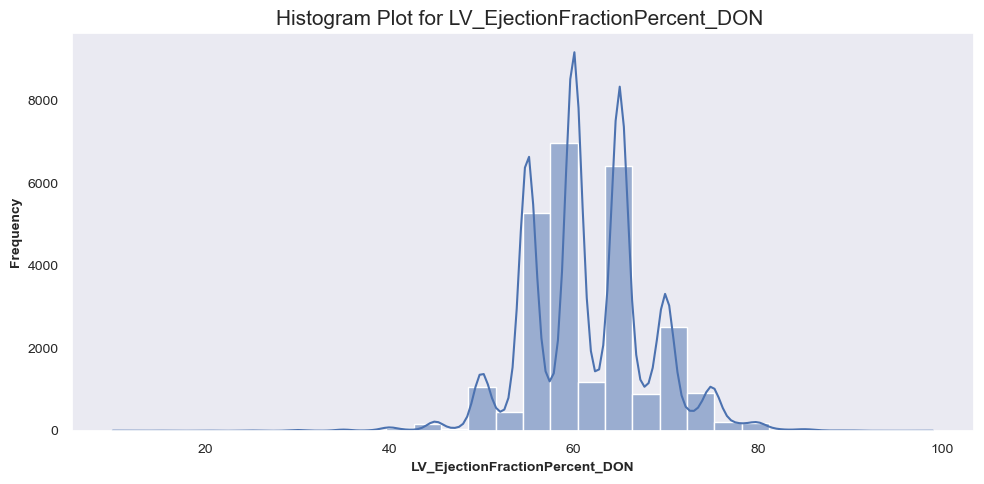

In [110]:
uv.histogramPlot(df_impute, features, bins=30)

In [111]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


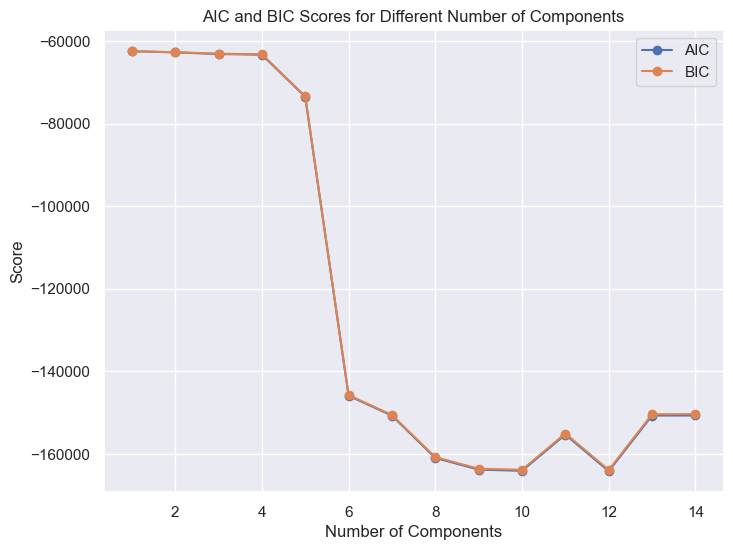

Optimal number of components: 12


In [112]:
# find components
ui.findGaussianMixtureComponents(df_impute[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [113]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=12)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


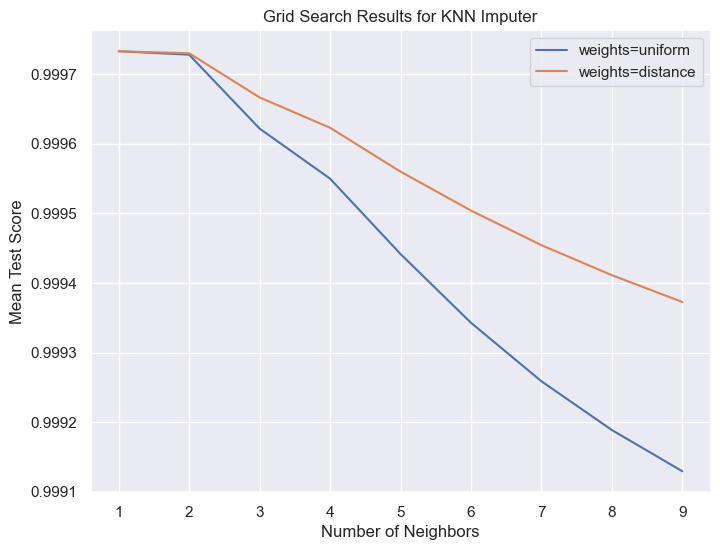

In [114]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [115]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
LV_EjectionFractionPercent_DON,26600.0,61.619198,6.642804,10.0,56.0,60.0,65.0,99.0


#### Weight

In [116]:
features = uf.getFeatureList(df_impute, 'WeightKg.*_CAN')

                count       mean        std   min   25%   50%   75%    max
WeightKg_CAN  26593.0  83.200113  18.073713  29.9  70.3  82.5  95.3  159.1

:::: NaN Count:
WeightKg_CAN    7


In [117]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


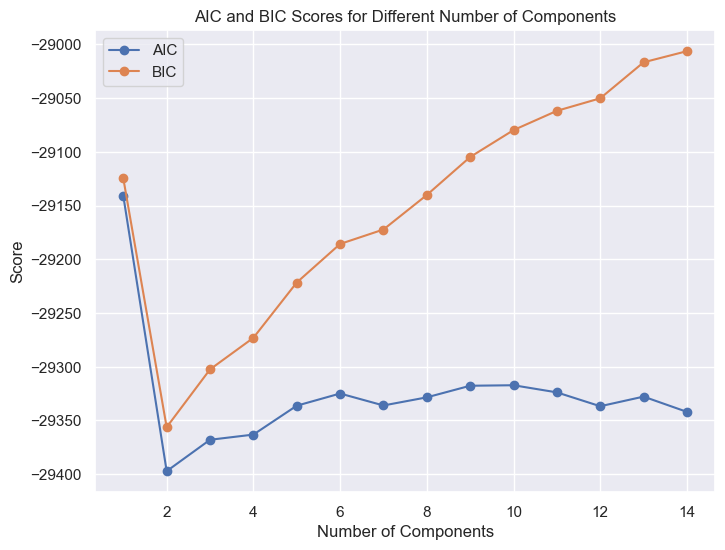

Optimal number of components: 2


In [118]:
# find components
ui.findGaussianMixtureComponents(df_impute[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [119]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=2)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


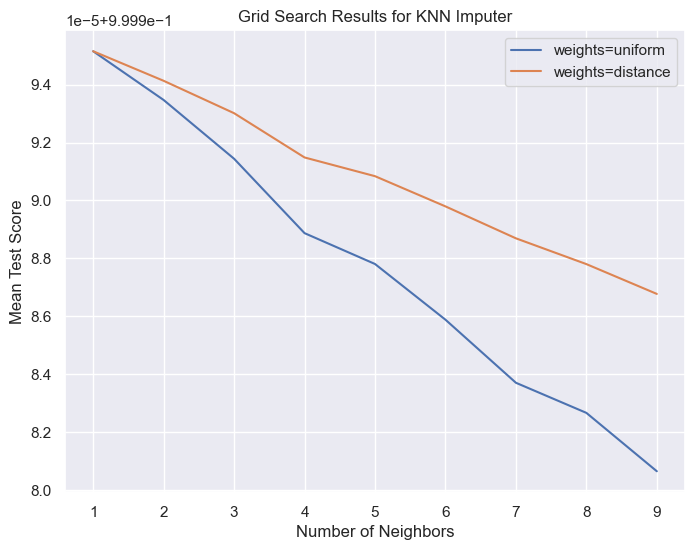

In [120]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [121]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
WeightKg_CAN,26600.0,83.199085,18.071853,29.9,70.3,82.5,95.3,159.1


In [122]:
features = uf.getFeatureList(df_impute, 'WeightKg.*_DON')

                count       mean       std   min   25%   50%   75%    max
WeightKg_DON  26597.0  83.449795  19.51705  23.2  70.0  80.6  94.0  198.0

:::: NaN Count:
WeightKg_DON    3


In [123]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


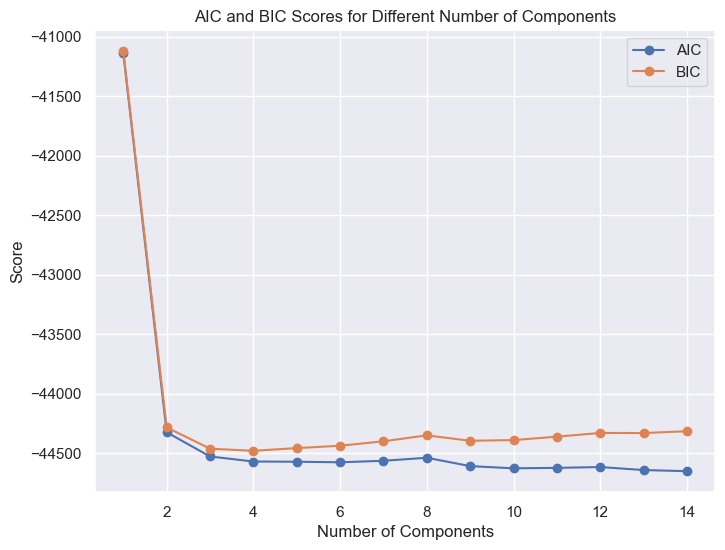

Optimal number of components: 4


In [124]:
# find components
ui.findGaussianMixtureComponents(df_impute[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [125]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=4)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


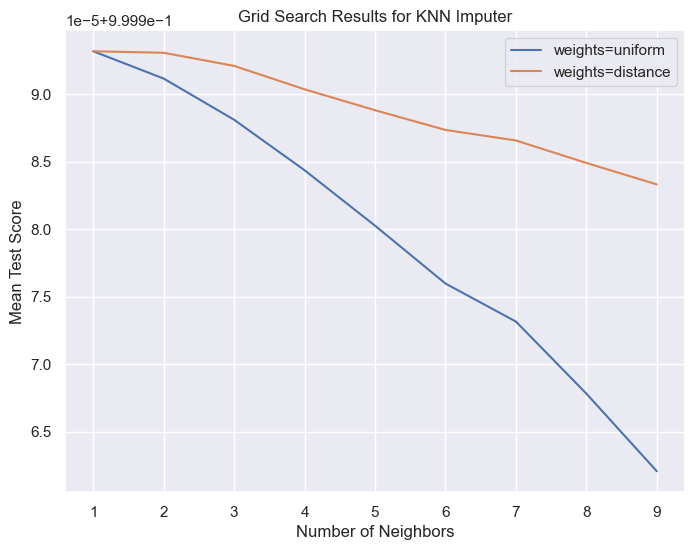

In [126]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [127]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
WeightKg_DON,26600.0,83.449402,19.516123,23.2,70.0,80.6,94.0,198.0


In [128]:
# update feature
df_impute['WeightKg_Difference'] = df_impute.WeightKg_CAN - df_impute.WeightKg_DON
df_impute['WeightKg_Addition'] = df_impute.WeightKg_CAN + df_impute.WeightKg_DON

In [129]:
features = uf.getFeatureList(df_impute, 'WeightKg')

                       count        mean        std    min    25%     50%    75%    max
WeightKg_Addition    26600.0  166.648487  32.258458   72.2  143.9  164.65  187.1  335.6
WeightKg_CAN         26600.0   83.199085  18.071853   29.9   70.3   82.50   95.3  159.1
WeightKg_DON         26600.0   83.449402  19.516123   23.2   70.0   80.60   94.0  198.0
WeightKg_Difference  26600.0   -0.250317  19.347707 -128.3  -11.4    1.30   12.6   86.5

:::: NaN Count:
WeightKg_Addition      0
WeightKg_CAN           0
WeightKg_DON           0
WeightKg_Difference    0


In [130]:
# calc BMI
df_impute['BMI_CAN'] = df_impute.WeightKg_CAN / np.square(df_impute.HeightCm_CAN * 0.01)
df_impute['BMI_DON'] = df_impute.WeightKg_DON / np.square(df_impute.HeightCm_DON * 0.01)

# update feature
df_impute['BMI_Difference'] = df_impute.BMI_CAN - df_impute.BMI_DON
df_impute['BMI_Addition'] = df_impute.BMI_CAN + df_impute.BMI_DON

### Update df & df_impute

In [131]:
# remove unwanted features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 3 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 1 row(s) from df_nominal DataFrame.
Remove 2 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['LungPO2_DON', 'LungPO2_Done_DON', 'LungPO2_FIO2_DON']

Total Row(s) & Column(s) Before Removing Column(s): 26,600 & columns: 236
Total Row(s) & Column(s) After Removing Column(s): 26,600 & columns: 233


In [132]:
# remove unwanted features Impute
df_impute, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df_impute, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['LungPO2_DON', 'LungPO2_Done_DON', 'LungPO2_FIO2_DON']

Total Row(s) & Column(s) Before Removing Column(s): 26,600 & columns: 236
Total Row(s) & Column(s) After Removing Column(s): 26,600 & columns: 233


#### Examine NaNs: Full Dataset

In [133]:
# get NaNs
NaNsDF = uf.percentageNull(df_impute)

# display NaNs
NaNsDF

,percentage,NaNCount


### Save

In [134]:
# heart dataset
uf.writeToFile(df, '5Heart_ML_Orig',path='../Data/', format='pkl')

# heart dataset
uf.writeToFile(df_impute, '5Heart_ML_Impute',path='../Data/', format='pkl')

# heart label
uf.writeToFile(df_label, '5Label_ML',path='../Data/', format='pkl')

# heart candidate
uf.writeToFile(df_can, '5CAN_ML', format='pkl')

# heart donor
uf.writeToFile(df_don, '5DON_ML', format='pkl')

# heart both
uf.writeToFile(df_both, '5BOTH_ML', format='pkl')

# heart nominal
uf.writeToFile(df_nominal, '5Nominal_ML', format='pkl')

# heart ordinal
uf.writeToFile(df_ordinal, '5Ordinal_ML', format='pkl')

# heart numeric
uf.writeToFile(df_numeric, '5Numeric_ML', format='pkl')

# heart drop
uf.writeToFile(df_drop, '5Drop_ML', format='pkl')

# heart new
uf.writeToFile(df_new, '5New_ML', format='pkl')

# heart object
uf.writeToFile(df_object, '5Object_ML', format='pkl')

# heart unknown
uf.writeToFile(df_unknown, '5Unknown_ML', format='pkl')

# heart date
uf.writeToFile(df_date, '5Date_ML', format='pkl')

# heart data dictionary
uf.writeToFile(df_dict, '5Dictionary_ML', format='pkl')

26,600 records written to ../Data/5Heart_ML_Orig.pkl
26,600 records written to ../Data/5Heart_ML_Impute.pkl
2 records written to ../Data/5Label_ML.pkl
127 records written to ../Data/5CAN_ML.pkl
87 records written to ../Data/5DON_ML.pkl
19 records written to ../Data/5BOTH_ML.pkl
165 records written to ../Data/5Nominal_ML.pkl
12 records written to ../Data/5Ordinal_ML.pkl
57 records written to ../Data/5Numeric_ML.pkl
24 records written to ../Data/5Drop_ML.pkl
22 records written to ../Data/5New_ML.pkl
0 records written to ../Data/5Object_ML.pkl
0 records written to ../Data/5Unknown_ML.pkl
0 records written to ../Data/5Date_ML.pkl
302 records written to ../Data/5Dictionary_ML.pkl
